# Pipeline preditivo completo para classificação de dígitos manuscritos com o dataset MNIST.

## Fase 1 - Carregamento e Análise Exploratória de Imagens (EDA)

Nesta etapa será realizado o carregamento e a análise inicial do dataset MNIST, buscando compreender sua estrutura e características antes do pré-processamento dos dados.

Serão executadas as seguintes ações:

* Carregamento do dataset MNIST;
* Verificação das dimensões e quantidade de imagens;
* Identificação das classes e análise da distribuição dos dígitos;
* Verificação do balanceamento entre as classes;
* Visualização de exemplos dos dígitos de 0 a 9 em uma grade 2×5;
* Análise da representação das imagens em 28×28 pixels e 784 features;
* Análise da escala de intensidade dos pixels, de 0 a 255;
* Geração e armazenamento das visualizações utilizadas na análise exploratória.


In [92]:
#Bibliotecas do projeto.

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np
from sklearn.metrics import accuracy_score
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import inspect


In [2]:
# Importação das funções do projeto.

import importlib
import src.avaliacao
import src.robustez
import src.imagens_proprias

from src.carregamento import carregar_dataset

from src.analise_exploratoria import (
    inspecionar_dados,
    visualizar_digitos
)

from src.tratamento_de_dados import (
    dividir_dados,
    verificar_dimensoes,
    verificar_distribuicao_classes,
    normalizar_dados,
    verificar_normalizacao
)

from src.modelos import (
    criar_knn,
    treinar_modelo,
    prever_modelo,
    criar_random_forest,
    criar_mlp
)

importlib.reload(src.avaliacao)

from src.avaliacao import (
    calcular_metricas,
    gerar_matriz_confusao,
    plotar_matriz_confusao,
    identificar_maior_confusao
)

importlib.reload(src.robustez)

from src.robustez import (
    remover_classes_treinamento,
    verificar_classes,
    selecionar_classes_teste,
    obter_probabilidades,
    analisar_previsoes_ood,
    calcular_matriz_confusao_ood,
    plotar_matriz_confusao_ood,
    analisar_confianca_ood,
    contar_confiancas_ood,
    plotar_distribuicao_previsoes_ood
)

importlib.reload(src.imagens_proprias)

from src.imagens_proprias import (
    carregar_imagem,
    converter_para_cinza,
    redimensionar_imagem,
    aumentar_contraste,
    inverter_cores,
    encontrar_bounding_box,
    centralizar_digito,
    normalizar_imagem,
    prever_imagem,
    plotar_previsao,
    preprocessar_imagem
)


In [3]:


X, y = carregar_dataset()

Baixando o dataset MNIST...
O Dataset MNIST foi carregado com sucesso!


### Inspeção inicial dos dados

Nesta etapa será realizada uma inspeção inicial do dataset para compreender sua estrutura, quantidade de imagens, número de features, classes existentes e distribuição dos exemplos entre os dígitos.

In [4]:

inspecionar_dados(X, y)


============================== Inspeção inicial do dataset ==============================

============================== Dimensão de x==============================
(70000, 784)

============================== Dimensão de y==============================
(70000,)

============================== Quantidade de imagens ==============================
70000

============================== Quantidade de features por imagem ==============================
784

============================== Quantidade de classes ==============================
10

============================== Distribuição das classes ==============================
Classe 0: 6903 imagens
Classe 1: 7877 imagens
Classe 2: 6990 imagens
Classe 3: 7141 imagens
Classe 4: 6824 imagens
Classe 5: 6313 imagens
Classe 6: 6876 imagens
Classe 7: 7293 imagens
Classe 8: 6825 imagens
Classe 9: 6958 imagens

============================== Análise do balanceamento ==============================
Classe com mais imagens: 1 (7877 imagens)
Classe 

### Análise da Inspeção Inicial dos Dados

Durante a inspeção inicial foi identificado que o dataset MNIST possui **70.000 imagens**, representadas por **784 features** cada, e **10 classes**, correspondentes aos dígitos de 0 a 9.

Cada imagem possui dimensão original de **28×28 pixels**.

Para utilização nos modelos de aprendizado de máquina, essas imagens são representadas como vetores contendo 784 valores, resultado da transformação de 28×28 pixels em uma única dimensão.

A variável `y` contém os rótulos correspondentes às imagens, apresentando as classes de 0 a 9. A análise da distribuição identificou diferenças na quantidade de exemplos entre as classes.

A classe 1 possui a maior quantidade de imagens, com **7.877 registros**, enquanto a classe 5 possui a menor quantidade, com **6.313 registros**.

A diferença entre a classe com maior e menor quantidade é de **1.564 imagens**.

Apesar dessa diferença, a distribuição das classes não apresenta uma concentração extrema em uma única classe, indicando que o dataset possui um **balanceamento razoável**.



### Visualização dos dígitos do dataset


Nesta etapa serão visualizados exemplos dos dígitos de 0 a 9, organizados em uma grade 2×5.

A visualização permite observar como as imagens estão representadas no dataset e confirmar a correspondência entre os pixels e seus respectivos rótulos.


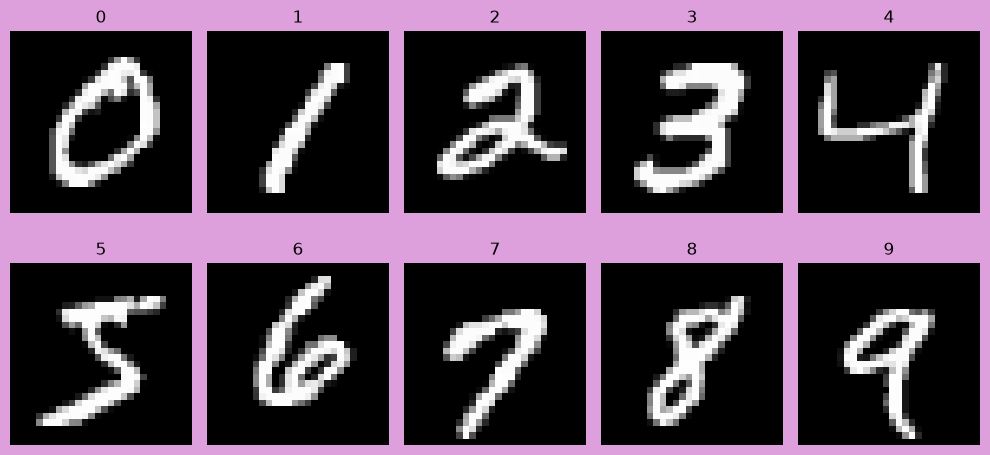

In [5]:
visualizar_digitos(X, y)

### Interpretação da visualização

A visualização apresenta exemplos das dez classes do dataset MNIST, correspondentes aos dígitos de 0 a 9. 

As imagens são representadas em uma matriz de **28×28 pixels** e apresentadas em escala de cinza.

Cada imagem possui **784 valores de pixels**, pois 28 × 28 = 784.

No dataset original, esses valores representam diferentes intensidades de cinza, variando de **0 a 255**, sendo que valores mais baixos representam regiões mais escuras e valores mais altos representam regiões mais claras.

A visualização também permite observar que existem diferenças na forma como cada dígito é escrito, mesmo pertencendo à mesma classe.

Essa variação entre as imagens é uma característica importante do problema de classificação, pois os modelos deverão aprender os padrões que permitem diferenciar os dígitos mesmo quando eles apresentam diferentes estilos de escrita.

A grade 2×5 facilita a inspeção das dez classes e confirma visualmente a correspondência entre as imagens e seus respectivos rótulos.


## **Fase 2 - Pipeline de Pré-processamento e Divisão dos Dados**

Nesta etapa será realizado o pré-processamento e a preparação do dataset MNIST para as etapas posteriores de treinamento e avaliação dos modelos de classificação.

Serão executadas as seguintes ações:

* Divisão do dataset em conjuntos de treino, validação e teste;

* Utilização da estratificação por classe para preservar a distribuição dos dígitos nos diferentes conjuntos;

* Definição da proporção de 70% para treino, 10% para validação e 20% para teste;

* Verificação das dimensões e quantidade de amostras presentes em cada conjunto;

* Verificação da distribuição das classes após a divisão dos dados;

* Normalização dos valores de intensidade dos pixels para o intervalo [0,0, 1,0];

* Verificação dos valores mínimos e máximos após a normalização;

* Garantia da separação adequada entre os dados utilizados no treinamento, validação e teste, evitando data leakage;



### Divisão dos dados

Nesta etapa será realizada a divisão do dataset MNIST em conjuntos de treino, validação e teste, utilizando estratificação por classe.

A divisão será feita na proporção de 70% para treino, 10% para validação e 20% para teste, garantindo que a distribuição dos dígitos de 0 a 9 seja preservada entre os diferentes conjuntos.


In [6]:
(
    X_treino,
    X_validacao,
    X_teste,
    y_treino,
    y_validacao,
    y_teste
) = dividir_dados(X, y)

In [7]:
verificar_dimensoes(
    X_treino,
    X_validacao,
    X_teste,
    y_treino,
    y_validacao,
    y_teste
)

Dimensões dos conjuntos:
X treino: (49000, 784)
X validação: (7000, 784)
X teste: (14000, 784)

Dimensões dos rótulos:
y treino: (49000,)
y validação: (7000,)
y teste: (14000,)


In [8]:
verificar_distribuicao_classes(
    y_treino,
    y_validacao,
    y_teste
)

Distribuição das classes:

Classe    Treino      % Treino    Validação     % Validação   Teste       % Teste   
0         4832        9.86        690           9.86          1381        9.86      
1         5514        11.25       788           11.26         1575        11.25     
2         4893        9.99        699           9.99          1398        9.99      
3         4999        10.20       714           10.20         1428        10.20     
4         4777        9.75        682           9.74          1365        9.75      
5         4419        9.02        631           9.01          1263        9.02      
6         4813        9.82        688           9.83          1375        9.82      
7         5105        10.42       729           10.41         1459        10.42     
8         4777        9.75        683           9.76          1365        9.75      
9         4871        9.94        696           9.94          1391        9.94      


### Conclusão da divisão


A distribuição das classes foi preservada de forma consistente entre os conjuntos de treino, validação e teste.

As proporções das classes apresentam diferenças mínimas entre os conjuntos, confirmando que a estratificação utilizada funcionou conforme o esperado.

Dessa forma, os conjuntos permanecem representativos da distribuição original do dataset MNIST, evitando uma concentração desproporcional de determinadas classes em algum dos conjuntos.


### Normalização dos Dados

Nesta etapa será realizada a normalização dos valores dos pixels das imagens do dataset.

Os pixels possuem valores de intensidade entre 0 e 255. Esses valores serão transformados para o intervalo [0, 1], dividindo cada valor por 255.

A normalização tem como objetivo colocar os atributos em uma escala adequada para o treinamento dos modelos, contribuindo para uma melhor convergência dos algoritmos e para comparações mais consistentes entre as features.

Após a normalização, serão verificadas as dimensões dos conjuntos e os valores mínimo e máximo para confirmar que os dados foram transformados corretamente.


In [9]:
(
    X_treino_normalizado,
    X_validacao_normalizado,
    X_teste_normalizado
) = normalizar_dados(
    X_treino,
    X_validacao,
    X_teste
)

In [10]:
verificar_normalizacao(
    X_treino_normalizado,
    X_validacao_normalizado,
    X_teste_normalizado
)

Verificação da normalização:

X treino:
Valor mínimo: 0.00
Valor máximo: 1.00
Dimensão: (49000, 784)

X validação:
Valor mínimo: 0.00
Valor máximo: 1.00
Dimensão: (7000, 784)

X teste:
Valor mínimo: 0.00
Valor máximo: 1.00
Dimensão: (14000, 784)


### Conclusão da normalização

A normalização dos dados foi realizada corretamente, transformando os valores de intensidade dos pixels do intervalo original de 0 a 255 para o intervalo de 0 a 1.

A verificação confirmou que os três conjuntos apresentam valores mínimos de 0,00 e máximos de 1,00, enquanto suas dimensões permaneceram inalteradas. Dessa forma, os dados estão normalizados e preparados para as etapas posteriores de treinamento e avaliação dos modelos.


### Verificação de Data Leakage

A preparação dos dados foi realizada mantendo a separação entre os conjuntos de treino, validação e teste. 

A divisão dos dados ocorreu antes da normalização, garantindo que os conjuntos permanecessem independentes durante o pré-processamento.

A normalização foi realizada por meio da divisão dos valores dos pixels por 255, uma transformação fixa que não depende de parâmetros calculados a partir dos dados.

Dessa forma, não foi utilizado nenhum parâmetro obtido do conjunto de teste durante o pré-processamento.

Portanto, não foi identificado data leakage na etapa de preparação dos dados, mantendo o conjunto de teste independente para a avaliação final dos modelos.


### **Conclusão da Fase 2**

Nesta etapa, o dataset MNIST foi preparado para as etapas de treinamento e avaliação dos modelos. 

Os dados foram divididos em conjuntos de treino, validação e teste, utilizando estratificação por classe e mantendo a proporção de 70%, 10% e 20%, respectivamente.

As verificações realizadas confirmaram que as dimensões dos dados foram preservadas e que a distribuição das classes permaneceu consistente entre os três conjuntos. Em seguida, os valores dos pixels foram normalizados de 0 a 255 para o intervalo de 0 a 1, sem alterar a estrutura dos dados.

Também foi verificado o processo de preparação quanto à possibilidade de data leakage. 

Como a divisão dos dados foi realizada antes do pré-processamento e a normalização utilizou uma transformação fixa, sem parâmetros calculados a partir dos dados, o conjunto de teste permaneceu independente.



## **Fase 3 - Implementação e Treinamento dos Modelos**

Nesta etapa será realizada a implementação e o treinamento de três modelos de classificação para o reconhecimento dos dígitos do dataset MNIST, utilizando os dados preparados na etapa de pré-processamento.

Serão executadas as seguintes ações:

* Implementação de três modelos de classificação distintos: K-Nearest Neighbors (KNN), Random Forest e Multi-Layer Perceptron (MLP);

* Definição e ajuste de pelo menos dois hiperparâmetros para cada modelo, buscando obter configurações adequadas ao problema de classificação;

* Justificativa das escolhas dos hiperparâmetros utilizados em cada modelo;

* Treinamento dos modelos utilizando exclusivamente o conjunto de dados de treino;

* Utilização do conjunto de validação para comparar e selecionar as configurações dos modelos;

* Registro do tempo de treinamento de cada modelo para posterior análise do custo computacional;

* Comparação dos resultados obtidos durante a etapa de validação;

* Seleção das configurações finais dos modelos para utilização na etapa de avaliação;


### K-Nearest Neighbors (KNN)

Nesta etapa será implementado e treinado o modelo K-Nearest Neighbors (KNN) para a classificação dos dígitos do dataset.

O KNN realiza a classificação de uma nova imagem com base nos exemplos mais próximos presentes no conjunto de treinamento.

Para isso, serão definidos e ajustados os hiperparâmetros `n_neighbors` e `weights`, que controlam a quantidade de vizinhos considerados e a influência de cada vizinho na classificação.

Durante os experimentos, diferentes valores de `n_neighbors` serão comparados utilizando o conjunto de validação, buscando identificar uma configuração que apresente bom desempenho para a classificação dos dígitos.

Também será registrado o tempo de treinamento do modelo, permitindo posteriormente comparar seu desempenho e custo computacional com os demais modelos.


In [11]:
resultados_knn = []

valores_n_neighbors = [3, 5, 7]
valores_weights = ["uniform", "distance"]

### Observação sobre custo computacional

Durante a implementação do experimento de ajuste dos hiperparâmetros do KNN, inicialmente foi testada a execução automática des seis combinações de `n_neighbors` e `weights` por meio de um laço de repetição.

Embora o treinamento individual do modelo tenha apresentado baixo tempo de execução, a execução das previsões para todas as seis configurações apresentou um tempo significativamente maior.

O experimento completo levou aproximadamente 6 minutos e 58,1 segundos no ambiente utilizado.

Esse comportamento está relacionado ao custo computacional da etapa de predição do KNN, que precisa calcular distâncias entre as imagens do conjunto de validação e os exemplos armazenados no conjunto de treinamento.

Diante dessa limitação computacional, optei por executar essas configurações individualmente. 

Essa abordagem permite acompanhar o tempo de cada experimento e evita manter uma sequência longa de processamentos sem acompanhamento, mantendo o mesmo conjunto de dados e a mesma metodologia de avaliação.

Esse resultado também será considerado posteriormente na análise do custo computacional dos modelos.


In [12]:
modelo_knn_1 = criar_knn(
    n_neighbors=3,
    weights="uniform"
)

modelo_knn_1, tempo_treinamento_knn_1 = treinar_modelo(
    modelo_knn_1,
    X_treino_normalizado,
    y_treino
)

previsoes_knn_1, tempo_predicao_knn_1 = prever_modelo(
    modelo_knn_1,
    X_validacao_normalizado
)

acuracia_knn_1 = accuracy_score(
    y_validacao,
    previsoes_knn_1
)

print(f"Acurácia: {acuracia_knn_1:.4f}")
print(f"Tempo de treinamento: {tempo_treinamento_knn_1:.2f} segundos")
print(f"Tempo de predição: {tempo_predicao_knn_1:.2f} segundos")

Acurácia: 0.9719
Tempo de treinamento: 0.33 segundos
Tempo de predição: 109.33 segundos


In [13]:
modelo_knn_2 = criar_knn(
    n_neighbors=3,
    weights="distance"
)

modelo_knn_2, tempo_treinamento_knn_2 = treinar_modelo(
    modelo_knn_2,
    X_treino_normalizado,
    y_treino
)

previsoes_knn_2, tempo_predicao_knn_2 = prever_modelo(
    modelo_knn_2,
    X_validacao_normalizado
)

acuracia_knn_2 = accuracy_score(
    y_validacao,
    previsoes_knn_2
)

print(f"Acurácia: {acuracia_knn_2:.4f}")
print(f"Tempo de treinamento: {tempo_treinamento_knn_2:.2f} segundos")
print(f"Tempo de predição: {tempo_predicao_knn_2:.2f} segundos")

Acurácia: 0.9723
Tempo de treinamento: 0.34 segundos
Tempo de predição: 95.99 segundos


In [14]:
modelo_knn_3 = criar_knn(
    n_neighbors=5,
    weights="uniform"
)

modelo_knn_3, tempo_treinamento_knn_3 = treinar_modelo(
    modelo_knn_3,
    X_treino_normalizado,
    y_treino
)

previsoes_knn_3, tempo_predicao_knn_3 = prever_modelo(
    modelo_knn_3,
    X_validacao_normalizado
)

acuracia_knn_3 = accuracy_score(
    y_validacao,
    previsoes_knn_3
)

print(f"Acurácia: {acuracia_knn_3:.4f}")
print(f"Tempo de treinamento: {tempo_treinamento_knn_3:.2f} segundos")
print(f"Tempo de predição: {tempo_predicao_knn_3:.2f} segundos")

Acurácia: 0.9694
Tempo de treinamento: 0.54 segundos
Tempo de predição: 64.51 segundos


In [15]:
modelo_knn_4 = criar_knn(
    n_neighbors=5,
    weights="distance"
)

modelo_knn_4, tempo_treinamento_knn_4 = treinar_modelo(
    modelo_knn_4,
    X_treino_normalizado,
    y_treino
)

previsoes_knn_4, tempo_predicao_knn_4 = prever_modelo(
    modelo_knn_4,
    X_validacao_normalizado
)

acuracia_knn_4 = accuracy_score(
    y_validacao,
    previsoes_knn_4
)

print(f"Acurácia: {acuracia_knn_4:.4f}")
print(f"Tempo de treinamento: {tempo_treinamento_knn_4:.2f} segundos")
print(f"Tempo de predição: {tempo_predicao_knn_4:.2f} segundos")

Acurácia: 0.9714
Tempo de treinamento: 0.24 segundos
Tempo de predição: 64.39 segundos


In [16]:
modelo_knn_5 = criar_knn(
    n_neighbors=7,
    weights="uniform"
)

modelo_knn_5, tempo_treinamento_knn_5 = treinar_modelo(
    modelo_knn_5,
    X_treino_normalizado,
    y_treino
)

previsoes_knn_5, tempo_predicao_knn_5 = prever_modelo(
    modelo_knn_5,
    X_validacao_normalizado
)

acuracia_knn_5 = accuracy_score(
    y_validacao,
    previsoes_knn_5
)

print(f"Acurácia: {acuracia_knn_5:.4f}")
print(f"Tempo de treinamento: {tempo_treinamento_knn_5:.2f} segundos")
print(f"Tempo de predição: {tempo_predicao_knn_5:.2f} segundos")

Acurácia: 0.9684
Tempo de treinamento: 0.27 segundos
Tempo de predição: 63.70 segundos


In [17]:
modelo_knn_6 = criar_knn(
    n_neighbors=7,
    weights="distance"
)

modelo_knn_6, tempo_treinamento_knn_6 = treinar_modelo(
    modelo_knn_6,
    X_treino_normalizado,
    y_treino
)

previsoes_knn_6, tempo_predicao_knn_6 = prever_modelo(
    modelo_knn_6,
    X_validacao_normalizado
)

acuracia_knn_6 = accuracy_score(
    y_validacao,
    previsoes_knn_6
)

print(f"Acurácia: {acuracia_knn_6:.4f}")
print(f"Tempo de treinamento: {tempo_treinamento_knn_6:.2f} segundos")
print(f"Tempo de predição: {tempo_predicao_knn_6:.2f} segundos")

Acurácia: 0.9699
Tempo de treinamento: 0.25 segundos
Tempo de predição: 64.88 segundos


In [18]:
resultados_knn = [
    {
        "Teste": 1,
        "n_neighbors": 3,
        "weights": "uniform",
        "Acurácia": acuracia_knn_1,
        "Tempo de treinamento (s)": tempo_treinamento_knn_1,
        "Tempo de predição (s)": tempo_predicao_knn_1
    },
    {
        "Teste": 2,
        "n_neighbors": 3,
        "weights": "distance",
        "Acurácia": acuracia_knn_2,
        "Tempo de treinamento (s)": tempo_treinamento_knn_2,
        "Tempo de predição (s)": tempo_predicao_knn_2
    },
    {
        "Teste": 3,
        "n_neighbors": 5,
        "weights": "uniform",
        "Acurácia": acuracia_knn_3,
        "Tempo de treinamento (s)": tempo_treinamento_knn_3,
        "Tempo de predição (s)": tempo_predicao_knn_3
    },
    {
        "Teste": 4,
        "n_neighbors": 5,
        "weights": "distance",
        "Acurácia": acuracia_knn_4,
        "Tempo de treinamento (s)": tempo_treinamento_knn_4,
        "Tempo de predição (s)": tempo_predicao_knn_4
    },
    {
        "Teste": 5,
        "n_neighbors": 7,
        "weights": "uniform",
        "Acurácia": acuracia_knn_5,
        "Tempo de treinamento (s)": tempo_treinamento_knn_5,
        "Tempo de predição (s)": tempo_predicao_knn_5
    },
    {
        "Teste": 6,
        "n_neighbors": 7,
        "weights": "distance",
        "Acurácia": acuracia_knn_6,
        "Tempo de treinamento (s)": tempo_treinamento_knn_6,
        "Tempo de predição (s)": tempo_predicao_knn_6
    }
]

In [19]:
resultados_knn = pd.DataFrame(resultados_knn)

resultados_knn

,Teste,n_neighbors,weights,Acurácia,Tempo de treinamento (s),Tempo de predição (s)
0,1,3,uniform,0.971857,0.334231,109.325101
1,2,3,distance,0.972286,0.338747,95.994377
2,3,5,uniform,0.969429,0.541271,64.509072
3,4,5,distance,0.971429,0.243003,64.386768
4,5,7,uniform,0.968429,0.274581,63.697871
5,6,7,distance,0.969857,0.248508,64.878905


### Comparação dos experimentos do KNN

A tabela a seguir apresenta os resultados obtidos nas seis combinações de hiperparâmetros testadas para o modelo KNN. A comparação considera a acurácia obtida no conjunto de validação, o tempo de treinamento e o tempo de predição.


In [20]:
resultados_knn_formatado = resultados_knn.copy()

resultados_knn_formatado["Acurácia"] = (
    resultados_knn_formatado["Acurácia"] * 100
).round(2).astype(str) + "%"

resultados_knn_formatado["Tempo de treinamento (s)"] = (
    resultados_knn_formatado["Tempo de treinamento (s)"].round(2)
)

resultados_knn_formatado["Tempo de predição (s)"] = (
    resultados_knn_formatado["Tempo de predição (s)"].round(2)
)

resultados_knn_formatado

,Teste,n_neighbors,weights,Acurácia,Tempo de treinamento (s),Tempo de predição (s)
0,1,3,uniform,97.19%,0.33,109.33
1,2,3,distance,97.23%,0.34,95.99
2,3,5,uniform,96.94%,0.54,64.51
3,4,5,distance,97.14%,0.24,64.39
4,5,7,uniform,96.84%,0.27,63.70
5,6,7,distance,96.99%,0.25,64.88


### **Análise dos resultados do KNN**

Foram avaliadas seis combinações dos hiperparâmetros `n_neighbors` e `weights`, utilizando o conjunto de validação para comparar o desempenho das configurações.

Os resultados apresentaram acurácias próximas, variando entre **96,84% e 97,23%**. A maior acurácia foi obtida no **Teste 2**, com `n_neighbors=3` e `weights="distance"`, alcançando **97,23%**.

Ao comparar o número de vizinhos, observa-se que o aumento de `n_neighbors` de 3 para 5 e 7 não proporcionou melhoria na acurácia. As configurações com 3 vizinhos apresentaram os melhores resultados, enquanto as configurações com 7 vizinhos apresentaram as menores acurácias.

Em relação ao hiperparâmetro `weights`, as configurações utilizando `"distance"` apresentaram acurácia superior às respectivas configurações utilizando `"uniform"` para os valores de `n_neighbors` testados. Isso indica que, neste experimento, considerar a distância dos vizinhos contribuiu para uma classificação ligeiramente melhor.

O tempo de treinamento foi baixo em todas as configurações, variando entre **0,24 e 0,54 segundos**. Já o tempo de predição foi significativamente maior, variando entre **63,70 e 109,33 segundos**, evidenciando que a etapa de predição representa o principal custo computacional do KNN neste experimento.

Com base nos resultados obtidos no conjunto de validação, foi selecionada a configuração do **Teste 2**, com `n_neighbors=3` e `weights="distance"`, por apresentar a maior acurácia entre as configurações avaliadas.



### **Configuração selecionada**

Com base nos experimentos realizados no conjunto de validação, foi selecionada a configuração do KNN com `n_neighbors=3` e `weights="distance"`.

Essa configuração apresentou a maior acurácia entre as seis combinações avaliadas, alcançando **97,23%**. Além disso, apresentou tempo de predição de **95,99 segundos**, inferior ao das configurações dos Testes 1, 3, 4, 5 e 6.

A escolha foi realizada exclusivamente com base nos resultados obtidos no conjunto de validação. O conjunto de teste não foi utilizado nessa etapa e permanecerá reservado para a avaliação final dos modelos na Fase 4.

Essa configuração será mantida como a configuração final do KNN para a etapa de avaliação.


### Random Forest

Nesta etapa será implementado e treinado o modelo Random Forest para a classificação dos dígitos do dataset.

O Random Forest realiza a classificação combinando as decisões de várias árvores de decisão, buscando obter um modelo mais robusto e capaz de lidar com diferentes padrões presentes nos dados.

Para isso, serão definidos e ajustados os hiperparâmetros `n_estimators` e `max_depth`, que controlam, respectivamente, a quantidade de árvores utilizadas no modelo e a profundidade máxima dessas árvores.

Durante os experimentos, diferentes combinações de `n_estimators` e `max_depth` serão comparadas utilizando o conjunto de validação, buscando identificar uma configuração que apresente bom desempenho para a classificação dos dígitos.

Também será registrado o tempo de treinamento e de predição do modelo, permitindo posteriormente comparar seu desempenho e custo computacional com os demais modelos.


In [21]:
modelo_rf = criar_random_forest(
    n_estimators=100,
    max_depth=10
)

In [22]:
modelo_rf_1, tempo_treinamento_rf_1 = treinar_modelo(
    modelo_rf,
    X_treino_normalizado,
    y_treino
)

previsoes_rf_1, tempo_predicao_rf_1 = prever_modelo(
    modelo_rf_1,
    X_validacao_normalizado
)

acuracia_rf_1 = accuracy_score(
    y_validacao,
    previsoes_rf_1
)

print(f"Acurácia: {acuracia_rf_1:.4f}")
print(f"Tempo de treinamento: {tempo_treinamento_rf_1:.2f} segundos")
print(f"Tempo de predição: {tempo_predicao_rf_1:.2f} segundos")

Acurácia: 0.9464
Tempo de treinamento: 70.00 segundos
Tempo de predição: 0.42 segundos


In [23]:
modelo_rf_2 = criar_random_forest(
    n_estimators=100,
    max_depth=20
)

modelo_rf_2, tempo_treinamento_rf_2 = treinar_modelo(
    modelo_rf_2,
    X_treino_normalizado,
    y_treino
)

previsoes_rf_2, tempo_predicao_rf_2 = prever_modelo(
    modelo_rf_2,
    X_validacao_normalizado
)

acuracia_rf_2 = accuracy_score(
    y_validacao,
    previsoes_rf_2
)

print(f"Acurácia: {acuracia_rf_2:.4f}")
print(f"Tempo de treinamento: {tempo_treinamento_rf_2:.2f} segundos")
print(f"Tempo de predição: {tempo_predicao_rf_2:.2f} segundos")

Acurácia: 0.9651
Tempo de treinamento: 101.05 segundos
Tempo de predição: 0.45 segundos


In [24]:
modelo_rf_3 = criar_random_forest(
    n_estimators=200,
    max_depth=10
)

modelo_rf_3, tempo_treinamento_rf_3 = treinar_modelo(
    modelo_rf_3,
    X_treino_normalizado,
    y_treino
)

previsoes_rf_3, tempo_predicao_rf_3 = prever_modelo(
    modelo_rf_3,
    X_validacao_normalizado
)

acuracia_rf_3 = accuracy_score(
    y_validacao,
    previsoes_rf_3
)

print(f"Acurácia: {acuracia_rf_3:.4f}")
print(f"Tempo de treinamento: {tempo_treinamento_rf_3:.2f} segundos")
print(f"Tempo de predição: {tempo_predicao_rf_3:.2f} segundos")

Acurácia: 0.9470
Tempo de treinamento: 124.32 segundos
Tempo de predição: 0.68 segundos


In [25]:
modelo_rf_4 = criar_random_forest(
    n_estimators=200,
    max_depth=20
)

modelo_rf_4, tempo_treinamento_rf_4 = treinar_modelo(
    modelo_rf_4,
    X_treino_normalizado,
    y_treino
)

previsoes_rf_4, tempo_predicao_rf_4 = prever_modelo(
    modelo_rf_4,
    X_validacao_normalizado
)

acuracia_rf_4 = accuracy_score(
    y_validacao,
    previsoes_rf_4
)

print(f"Acurácia: {acuracia_rf_4:.4f}")
print(f"Tempo de treinamento: {tempo_treinamento_rf_4:.2f} segundos")
print(f"Tempo de predição: {tempo_predicao_rf_4:.2f} segundos")

Acurácia: 0.9667
Tempo de treinamento: 162.55 segundos
Tempo de predição: 0.90 segundos


In [26]:
modelo_rf_5 = criar_random_forest(
    n_estimators=300,
    max_depth=10
)

modelo_rf_5, tempo_treinamento_rf_5 = treinar_modelo(
    modelo_rf_5,
    X_treino_normalizado,
    y_treino
)

previsoes_rf_5, tempo_predicao_rf_5 = prever_modelo(
    modelo_rf_5,
    X_validacao_normalizado
)

acuracia_rf_5 = accuracy_score(
    y_validacao,
    previsoes_rf_5
)

print(f"Acurácia: {acuracia_rf_5:.4f}")
print(f"Tempo de treinamento: {tempo_treinamento_rf_5:.2f} segundos")
print(f"Tempo de predição: {tempo_predicao_rf_5:.2f} segundos")

Acurácia: 0.9479
Tempo de treinamento: 201.14 segundos
Tempo de predição: 1.14 segundos


In [27]:
modelo_rf_6 = criar_random_forest(
    n_estimators=300,
    max_depth=20
)

modelo_rf_6, tempo_treinamento_rf_6 = treinar_modelo(
    modelo_rf_6,
    X_treino_normalizado,
    y_treino
)

previsoes_rf_6, tempo_predicao_rf_6 = prever_modelo(
    modelo_rf_6,
    X_validacao_normalizado
)

acuracia_rf_6 = accuracy_score(
    y_validacao,
    previsoes_rf_6
)

print(f"Acurácia: {acuracia_rf_6:.4f}")
print(f"Tempo de treinamento: {tempo_treinamento_rf_6:.2f} segundos")
print(f"Tempo de predição: {tempo_predicao_rf_6:.2f} segundos")

Acurácia: 0.9671
Tempo de treinamento: 285.57 segundos
Tempo de predição: 1.56 segundos


In [28]:
resultados_rf = [
    {
        "Teste": 1,
        "n_estimators": 100,
        "max_depth": 10,
        "Acurácia": acuracia_rf_1,
        "Tempo de treinamento (s)": tempo_treinamento_rf_1,
        "Tempo de predição (s)": tempo_predicao_rf_1
    },
    {
        "Teste": 2,
        "n_estimators": 100,
        "max_depth": 20,
        "Acurácia": acuracia_rf_2,
        "Tempo de treinamento (s)": tempo_treinamento_rf_2,
        "Tempo de predição (s)": tempo_predicao_rf_2
    },
    {
        "Teste": 3,
        "n_estimators": 200,
        "max_depth": 10,
        "Acurácia": acuracia_rf_3,
        "Tempo de treinamento (s)": tempo_treinamento_rf_3,
        "Tempo de predição (s)": tempo_predicao_rf_3
    },
    {
        "Teste": 4,
        "n_estimators": 200,
        "max_depth": 20,
        "Acurácia": acuracia_rf_4,
        "Tempo de treinamento (s)": tempo_treinamento_rf_4,
        "Tempo de predição (s)": tempo_predicao_rf_4
    },
    {
        "Teste": 5,
        "n_estimators": 300,
        "max_depth": 10,
        "Acurácia": acuracia_rf_5,
        "Tempo de treinamento (s)": tempo_treinamento_rf_5,
        "Tempo de predição (s)": tempo_predicao_rf_5
    },
    {
        "Teste": 6,
        "n_estimators": 300,
        "max_depth": 20,
        "Acurácia": acuracia_rf_6,
        "Tempo de treinamento (s)": tempo_treinamento_rf_6,
        "Tempo de predição (s)": tempo_predicao_rf_6
    }
]

resultados_rf = pd.DataFrame(resultados_rf)

resultados_rf

,Teste,n_estimators,max_depth,Acurácia,Tempo de treinamento (s),Tempo de predição (s)
0,1,100,10,0.946429,69.995884,0.418451
1,2,100,20,0.965143,101.046405,0.450608
2,3,200,10,0.947000,124.320019,0.677387
3,4,200,20,0.966714,162.551513,0.902333
4,5,300,10,0.947857,201.136035,1.140024
5,6,300,20,0.967143,285.574590,1.564108


### Comparação dos experimentos do Random Forest

A tabela a seguir apresenta os resultados obtidos nas seis combinações de hiperparâmetros testadas para o modelo Random Forest.
 A comparação considera a acurácia obtida no conjunto de validação, o tempo de treinamento e o tempo de predição.


In [29]:
resultados_rf_formatado = resultados_rf.copy()

resultados_rf_formatado["Acurácia"] = (
    resultados_rf_formatado["Acurácia"] * 100
).round(2).astype(str) + "%"

resultados_rf_formatado["Tempo de treinamento (s)"] = (
    resultados_rf_formatado["Tempo de treinamento (s)"].round(2)
)

resultados_rf_formatado["Tempo de predição (s)"] = (
    resultados_rf_formatado["Tempo de predição (s)"].round(2)
)

resultados_rf_formatado

,Teste,n_estimators,max_depth,Acurácia,Tempo de treinamento (s),Tempo de predição (s)
0,1,100,10,94.64%,70.00,0.42
1,2,100,20,96.51%,101.05,0.45
2,3,200,10,94.7%,124.32,0.68
3,4,200,20,96.67%,162.55,0.90
4,5,300,10,94.79%,201.14,1.14
5,6,300,20,96.71%,285.57,1.56


### **Análise dos resultados do Random Forest**

Foram avaliadas seis combinações dos hiperparâmetros `n_estimators` e `max_depth`, utilizando o conjunto de validação para comparar o desempenho das configurações.

Os resultados apresentaram acurácias entre **94,64% e 96,71%**. A maior acurácia foi obtida no **Teste 6**, com `n_estimators=300` e `max_depth=20`, alcançando **96,71%**.

Ao comparar o hiperparâmetro `max_depth`, observa-se que o aumento da profundidade máxima de 10 para 20 proporcionou uma melhoria significativa na acurácia.

Para 100 árvores, a acurácia passou de **94,64% para 96,51%**. Com 200 árvores, passou de **94,70% para 96,67%**, enquanto com 300 árvores passou de **94,79% para 96,71%**.

Isso indica que, neste experimento, permitir árvores mais profundas contribuiu para melhorar o desempenho do modelo.

Em relação ao hiperparâmetro `n_estimators`, o aumento da quantidade de árvores apresentou ganhos menores de acurácia quando `max_depth` foi mantido em 10.

Nesse caso, a acurácia variou de **94,64% para 94,79%** ao aumentar de 100 para 300 árvores. Com `max_depth=20`, o aumento de 100 para 300 árvores elevou a acurácia de **96,51% para 96,71%**.

Portanto, o aumento do número de árvores proporcionou uma melhoria pequena quando comparado ao impacto observado pelo aumento da profundidade.

O tempo de treinamento aumentou conforme a quantidade de árvores e a profundidade das árvores foram ampliadas, variando entre **70,00 e 285,57 segundos**.

O tempo de predição também aumentou, variando entre **0,42 e 1,56 segundos**. Esses resultados mostram que configurações mais complexas proporcionaram maior custo computacional.

Com base nos resultados obtidos no conjunto de validação, foi selecionada a configuração do **Teste 6**, com `n_estimators=300` e `max_depth=20`, por apresentar a maior acurácia entre as configurações avaliadas, alcançando **96,71%**.


### **Configuração selecionada**

Com base nos experimentos realizados no conjunto de validação, foi selecionada a configuração do Random Forest com `n_estimators=300` e `max_depth=20`.

Essa configuração apresentou a maior acurácia entre as seis combinações avaliadas, alcançando **96,71%**.

Além disso, apresentou tempo de predição de **1,56 segundos**.

A escolha foi realizada exclusivamente com base nos resultados obtidos no conjunto de validação.

O conjunto de teste não foi utilizado nessa etapa e permanecerá reservado para a avaliação final dos modelos na Fase 4.

Essa configuração será mantida como a configuração final do Random Forest para a etapa de avaliação.



### MLP (Multi-Layer Perceptron)

Nesta etapa será implementado e treinado o modelo MLP (Multi-Layer Perceptron) para a classificação dos dígitos do dataset.

O MLP é uma rede neural artificial composta por camadas de neurônios que aprendem padrões presentes nos dados durante o treinamento, buscando realizar a classificação dos diferentes dígitos.

Para os experimentos, serão definidos e ajustados os hiperparâmetros `hidden_layer_sizes` e `learning_rate_init`, que controlam, respectivamente, a quantidade de neurônios na camada oculta e a taxa de aprendizado utilizada durante o treinamento.

Durante os experimentos, diferentes combinações de quantidade de neurônios e taxa de aprendizado serão comparadas utilizando o conjunto de validação, buscando identificar uma configuração que apresente bom desempenho para a classificação dos dígitos.

Também será registrado o tempo de treinamento e de predição do modelo, permitindo posteriormente comparar seu desempenho e custo computacional com os demais modelos.


In [30]:
modelo_mlp = criar_mlp()

modelo_mlp

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(10,)"
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [31]:
modelo_mlp = criar_mlp(
    hidden_layer_sizes=(10,),
    learning_rate_init=0.001
)

modelo_mlp_1, tempo_treinamento_mlp_1 = treinar_modelo(
    modelo_mlp,
    X_treino_normalizado,
    y_treino
)

previsoes_mlp_1, tempo_predicao_mlp_1 = prever_modelo(
    modelo_mlp_1,
    X_validacao_normalizado
)

acuracia_mlp_1 = accuracy_score(
    y_validacao,
    previsoes_mlp_1
)

print(f"Acurácia: {acuracia_mlp_1:.4f}")
print(f"Tempo de treinamento: {tempo_treinamento_mlp_1:.2f} segundos")
print(f"Tempo de predição: {tempo_predicao_mlp_1:.2f} segundos")

c:\Users\franc\OneDrive\Desktop\Projetos\Curso\MNIST_Classification\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Acurácia: 0.9370
Tempo de treinamento: 415.90 segundos
Tempo de predição: 0.26 segundos


In [32]:
modelo_mlp = criar_mlp(
    hidden_layer_sizes=(10,),
    learning_rate_init=0.01
)

modelo_mlp_2, tempo_treinamento_mlp_2 = treinar_modelo(
    modelo_mlp,
    X_treino_normalizado,
    y_treino
)

previsoes_mlp_2, tempo_predicao_mlp_2 = prever_modelo(
    modelo_mlp_2,
    X_validacao_normalizado
)

acuracia_mlp_2 = accuracy_score(
    y_validacao,
    previsoes_mlp_2
)

print(f"Acurácia: {acuracia_mlp_2:.4f}")
print(f"Tempo de treinamento: {tempo_treinamento_mlp_2:.2f} segundos")
print(f"Tempo de predição: {tempo_predicao_mlp_2:.2f} segundos")

Acurácia: 0.9314
Tempo de treinamento: 272.70 segundos
Tempo de predição: 0.55 segundos


In [33]:
modelo_mlp = criar_mlp(
    hidden_layer_sizes=(20,),
    learning_rate_init=0.001
)

modelo_mlp_3, tempo_treinamento_mlp_3 = treinar_modelo(
    modelo_mlp,
    X_treino_normalizado,
    y_treino
)

previsoes_mlp_3, tempo_predicao_mlp_3 = prever_modelo(
    modelo_mlp_3,
    X_validacao_normalizado
)

acuracia_mlp_3 = accuracy_score(
    y_validacao,
    previsoes_mlp_3
)

print(f"Acurácia: {acuracia_mlp_3:.4f}")
print(f"Tempo de treinamento: {tempo_treinamento_mlp_3:.2f} segundos")
print(f"Tempo de predição: {tempo_predicao_mlp_3:.2f} segundos")

c:\Users\franc\OneDrive\Desktop\Projetos\Curso\MNIST_Classification\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Acurácia: 0.9476
Tempo de treinamento: 683.45 segundos
Tempo de predição: 0.60 segundos


In [34]:
modelo_mlp = criar_mlp(
    hidden_layer_sizes=(20,),
    learning_rate_init=0.01
)

modelo_mlp_4, tempo_treinamento_mlp_4 = treinar_modelo(
    modelo_mlp,
    X_treino_normalizado,
    y_treino
)

previsoes_mlp_4, tempo_predicao_mlp_4 = prever_modelo(
    modelo_mlp_4,
    X_validacao_normalizado
)

acuracia_mlp_4 = accuracy_score(
    y_validacao,
    previsoes_mlp_4
)

print(f"Acurácia: {acuracia_mlp_4:.4f}")
print(f"Tempo de treinamento: {tempo_treinamento_mlp_4:.2f} segundos")
print(f"Tempo de predição: {tempo_predicao_mlp_4:.2f} segundos")

Acurácia: 0.9379
Tempo de treinamento: 430.95 segundos
Tempo de predição: 2.04 segundos


In [35]:
modelo_mlp = criar_mlp(
    hidden_layer_sizes=(30,),
    learning_rate_init=0.001
)

modelo_mlp_5, tempo_treinamento_mlp_5 = treinar_modelo(
    modelo_mlp,
    X_treino_normalizado,
    y_treino
)

previsoes_mlp_5, tempo_predicao_mlp_5 = prever_modelo(
    modelo_mlp_5,
    X_validacao_normalizado
)

acuracia_mlp_5 = accuracy_score(
    y_validacao,
    previsoes_mlp_5
)

print(f"Acurácia: {acuracia_mlp_5:.4f}")
print(f"Tempo de treinamento: {tempo_treinamento_mlp_5:.2f} segundos")
print(f"Tempo de predição: {tempo_predicao_mlp_5:.2f} segundos")

Acurácia: 0.9613
Tempo de treinamento: 895.52 segundos
Tempo de predição: 1.06 segundos


In [36]:
modelo_mlp = criar_mlp(
    hidden_layer_sizes=(30,),
    learning_rate_init=0.01
)

modelo_mlp_6, tempo_treinamento_mlp_6 = treinar_modelo(
    modelo_mlp,
    X_treino_normalizado,
    y_treino
)

previsoes_mlp_6, tempo_predicao_mlp_6 = prever_modelo(
    modelo_mlp_6,
    X_validacao_normalizado
)

acuracia_mlp_6 = accuracy_score(
    y_validacao,
    previsoes_mlp_6
)

print(f"Acurácia: {acuracia_mlp_6:.4f}")
print(f"Tempo de treinamento: {tempo_treinamento_mlp_6:.2f} segundos")
print(f"Tempo de predição: {tempo_predicao_mlp_6:.2f} segundos")

Acurácia: 0.9577
Tempo de treinamento: 333.69 segundos
Tempo de predição: 1.24 segundos


In [37]:
resultados_mlp = [
    {
        "Teste": 1,
        "Neurônios": 10,
        "Learning rate": 0.001,
        "Acurácia": acuracia_mlp_1,
        "Tempo de treinamento (s)": tempo_treinamento_mlp_1,
        "Tempo de predição (s)": tempo_predicao_mlp_1
    },
    {
        "Teste": 2,
        "Neurônios": 10,
        "Learning rate": 0.01,
        "Acurácia": acuracia_mlp_2,
        "Tempo de treinamento (s)": tempo_treinamento_mlp_2,
        "Tempo de predição (s)": tempo_predicao_mlp_2
    },
    {
        "Teste": 3,
        "Neurônios": 20,
        "Learning rate": 0.001,
        "Acurácia": acuracia_mlp_3,
        "Tempo de treinamento (s)": tempo_treinamento_mlp_3,
        "Tempo de predição (s)": tempo_predicao_mlp_3
    },
    {
        "Teste": 4,
        "Neurônios": 20,
        "Learning rate": 0.01,
        "Acurácia": acuracia_mlp_4,
        "Tempo de treinamento (s)": tempo_treinamento_mlp_4,
        "Tempo de predição (s)": tempo_predicao_mlp_4
    },
    {
        "Teste": 5,
        "Neurônios": 30,
        "Learning rate": 0.001,
        "Acurácia": acuracia_mlp_5,
        "Tempo de treinamento (s)": tempo_treinamento_mlp_5,
        "Tempo de predição (s)": tempo_predicao_mlp_5
    },
    {
        "Teste": 6,
        "Neurônios": 30,
        "Learning rate": 0.01,
        "Acurácia": acuracia_mlp_6,
        "Tempo de treinamento (s)": tempo_treinamento_mlp_6,
        "Tempo de predição (s)": tempo_predicao_mlp_6
    }
]

resultados_mlp = pd.DataFrame(resultados_mlp)

resultados_mlp

,Teste,Neurônios,Learning rate,Acurácia,Tempo de treinamento (s),Tempo de predição (s)
0,1,10,0.001,0.937000,415.904942,0.260032
1,2,10,0.010,0.931429,272.701398,0.554149
2,3,20,0.001,0.947571,683.452052,0.599997
3,4,20,0.010,0.937857,430.950193,2.044019
4,5,30,0.001,0.961286,895.515641,1.063635
5,6,30,0.010,0.957714,333.694242,1.244782


### Comparação dos experimentos do MLP

A tabela a seguir apresenta os resultados obtidos nas seis combinações de hiperparâmetros testadas para o modelo MLP.

A comparação considera a acurácia obtida no conjunto de validação, o tempo de treinamento e o tempo de predição.

Os experimentos foram realizados variando a quantidade de neurônios na camada oculta e a taxa de aprendizado, permitindo analisar como essas configurações influenciam o desempenho e o custo computacional do modelo.


In [38]:
resultados_mlp_formatado = resultados_mlp.copy()

resultados_mlp_formatado["Acurácia"] = (
    resultados_mlp_formatado["Acurácia"] * 100
).round(2).astype(str) + "%"

resultados_mlp_formatado["Tempo de treinamento (s)"] = (
    resultados_mlp_formatado["Tempo de treinamento (s)"].round(2)
)

resultados_mlp_formatado["Tempo de predição (s)"] = (
    resultados_mlp_formatado["Tempo de predição (s)"].round(2)
)

resultados_mlp_formatado

,Teste,Neurônios,Learning rate,Acurácia,Tempo de treinamento (s),Tempo de predição (s)
0,1,10,0.001,93.7%,415.90,0.26
1,2,10,0.010,93.14%,272.70,0.55
2,3,20,0.001,94.76%,683.45,0.60
3,4,20,0.010,93.79%,430.95,2.04
4,5,30,0.001,96.13%,895.52,1.06
5,6,30,0.010,95.77%,333.69,1.24


### **Análise dos resultados do MLP**

Foram avaliadas seis combinações dos hiperparâmetros `hidden_layer_sizes` e `learning_rate_init`, utilizando o conjunto de validação para comparar o desempenho das diferentes configurações.

Os resultados apresentaram acurácias entre **93,14% e 96,13%**. A maior acurácia foi obtida no **Teste 5**, com 30 neurônios na camada oculta e `learning_rate_init=0.001`, alcançando **96,13%**.

Ao comparar a quantidade de neurônios, observa-se que o aumento de 10 para 20 neurônios proporcionou uma melhoria na acurácia quando utilizada a taxa de aprendizado de 0.001. A acurácia passou de **93,70%** no Teste 1 para **94,76%** no Teste 3.

Com 30 neurônios, a acurácia aumentou novamente, alcançando **96,13%** no Teste 5.

Quando utilizada a taxa de aprendizado de 0.01, o comportamento foi diferente. A acurácia foi de **93,14%** com 10 neurônios, passou para **93,79%** com 20 neurônios e chegou a **95,77%** com 30 neurônios.

Esses resultados indicam que, nos experimentos realizados, o aumento da quantidade de neurônios contribuiu para melhorar o desempenho do MLP, principalmente quando utilizada a taxa de aprendizado de 0.001.

Em relação ao hiperparâmetro `learning_rate_init`, a taxa de aprendizado de **0.001 apresentou as maiores acurácias** para as três quantidades de neurônios avaliadas. Com 10 neurônios, a acurácia foi de 93,70%, enquanto com 0.01 foi de 93,14%.

Com 20 neurônios, os resultados foram 94,76% e 93,79%, respectivamente.

Já com 30 neurônios, foram obtidas acurácias de 96,13% e 95,77%.

Portanto, neste experimento, a taxa de aprendizado de 0.001 apresentou melhor desempenho em todas as configurações de quantidade de neurônios avaliadas.

O tempo de treinamento variou entre **272,70 e 895,52 segundos**. De modo geral, configurações com maior quantidade de neurônios apresentaram maior custo computacional, principalmente quando utilizada a taxa de aprendizado de 0.001.

O tempo de predição variou entre **0,26 e 2,04 segundos**, apresentando diferenças menores quando comparado ao tempo necessário para o treinamento.

Com base nos resultados obtidos no conjunto de validação, foi selecionada a configuração do **Teste 5**, com **30 neurônios na camada oculta** e `learning_rate_init=0.001`, por apresentar a maior acurácia entre as configurações avaliadas, alcançando **96,13%**.



### **Configuração selecionada**

Com base nos experimentos realizados no conjunto de validação, foi selecionada a configuração do MLP com **30 neurônios na camada oculta** e `learning_rate_init=0.001`.

Essa configuração apresentou a maior acurácia entre as seis combinações avaliadas, alcançando **96,13%**.

Além disso, apresentou tempo de predição de **1,06 segundos**.

A escolha foi realizada exclusivamente com base nos resultados obtidos no conjunto de validação.

O conjunto de teste não foi utilizado nessa etapa e permanecerá reservado para a avaliação final dos modelos na Fase 4.

Essa configuração será mantida como a configuração final do MLP para a etapa de avaliação.


### **Conclusão da Fase 3**

Nesta etapa, foram implementados e treinados três modelos de classificação para o dataset MNIST: KNN, Random Forest e MLP.

Para cada modelo, foram realizados seis experimentos com diferentes combinações de hiperparâmetros, permitindo comparar o desempenho das configurações utilizando o conjunto de validação.

As avaliações consideraram a acurácia obtida na validação, o tempo de treinamento e o tempo de predição. A partir desses resultados, foi selecionada a melhor configuração de cada modelo, mantendo como critério principal o desempenho no conjunto de validação.

Para o KNN, foram avaliados diferentes valores de `n_neighbors` e `weights`. No Random Forest, foram comparados `n_estimators` e `max_depth`. Já no MLP, foram avaliadas diferentes quantidades de neurônios na camada oculta e taxas de aprendizado.

Ao final da etapa, foram definidas as configurações que apresentaram os melhores resultados para cada modelo. O conjunto de teste não foi utilizado durante os experimentos, permanecendo reservado para a avaliação final dos modelos na Fase 4.


## **Fase 4 - Avaliação Comparativa de Desempenho**

Nesta etapa será realizada a avaliação dos três modelos selecionados na etapa anterior, utilizando exclusivamente o conjunto de teste, que permaneceu separado durante todo o processo de treinamento e seleção dos modelos.

Serão executadas as seguintes ações:

* Treinamento dos três modelos utilizando as configurações finais selecionadas na etapa de validação;

* Realização das previsões sobre o conjunto de teste independente;

* Cálculo das métricas de desempenho dos modelos: Acurácia, Precisão, Recall e F1-score ponderados;

* Geração das matrizes de confusão 10x10 para análise dos acertos e erros de classificação de cada modelo;

* Identificação dos pares de dígitos que apresentam maior confusão entre as classes;

* Comparação dos resultados obtidos pelos três modelos por meio de uma tabela consolidada;

* Análise do desempenho dos modelos considerando tanto as métricas de classificação quanto o custo computacional;


### **Avaliação do KNN**

O K-Nearest Neighbors (KNN) será avaliado utilizando a configuração selecionada durante a etapa de validação da Fase 3, definida com `n_neighbors=3` e `weights="distance"`.

Nesta etapa, o modelo será treinado novamente utilizando o conjunto de treino e, posteriormente, realizará previsões sobre o conjunto de teste, que permaneceu separado durante as etapas anteriores. 

Os resultados obtidos serão utilizados para calcular as métricas de desempenho, gerar a matriz de confusão e analisar os principais erros de classificação do modelo.

Essa avaliação permitirá verificar o desempenho do KNN em dados que não foram utilizados durante seu treinamento ou seleção de hiperparâmetros, proporcionando uma análise mais adequada da capacidade de generalização do modelo.

In [39]:
knn = criar_knn(
    n_neighbors=3,
    weights="distance"
)

knn, tempo_treinamento_knn = treinar_modelo(
    knn,
    X_treino_normalizado,
    y_treino
)

previsoes_knn, tempo_predicao_knn = prever_modelo(
    knn,
    X_teste_normalizado
)

print(f"Tempo de treinamento: {tempo_treinamento_knn:.2f} segundos")
print(f"Tempo de predição: {tempo_predicao_knn:.2f} segundos")

Tempo de treinamento: 0.48 segundos
Tempo de predição: 169.30 segundos


In [40]:
metricas_knn = calcular_metricas(
    y_teste,
    previsoes_knn
)

print("Métricas do KNN:")
for metrica, valor in metricas_knn.items():
    print(f"{metrica}: {valor:.4f}")

Métricas do KNN:
Acurácia: 0.9721
Precisão: 0.9724
Recall: 0.9721
F1-score: 0.9721


In [41]:
matriz_knn = gerar_matriz_confusao(
    y_teste,
    previsoes_knn
)

print("Dimensão da matriz:", matriz_knn.shape)
print(matriz_knn)

Dimensão da matriz: (10, 10)
[[1375    1    0    0    0    0    3    0    1    1]
 [   0 1565    3    3    1    0    0    3    0    0]
 [  11   11 1341    5    2    0    4   20    4    0]
 [   1    1    6 1387    0   14    1    7    6    5]
 [   2   17    0    0 1304    0    5    2    0   35]
 [   5    3    1    9    1 1216   18    2    2    6]
 [   5    5    0    0    1    3 1359    0    2    0]
 [   2   14    3    0    1    0    0 1429    0   10]
 [   8    8    1   16    2   25    2    2 1291   10]
 [   1    7    0    6   13    2    1   16    2 1343]]


### **Matriz de Confusão do KNN**

A matriz de confusão abaixo apresenta a distribuição das classificações realizadas pelo KNN no conjunto de teste. Os valores da diagonal principal representam as classificações corretas, enquanto os valores fora da diagonal representam os erros de classificação.

A maior confusão observada foi entre os dígitos **4 e 9**, conforme identificado pela análise da matriz.

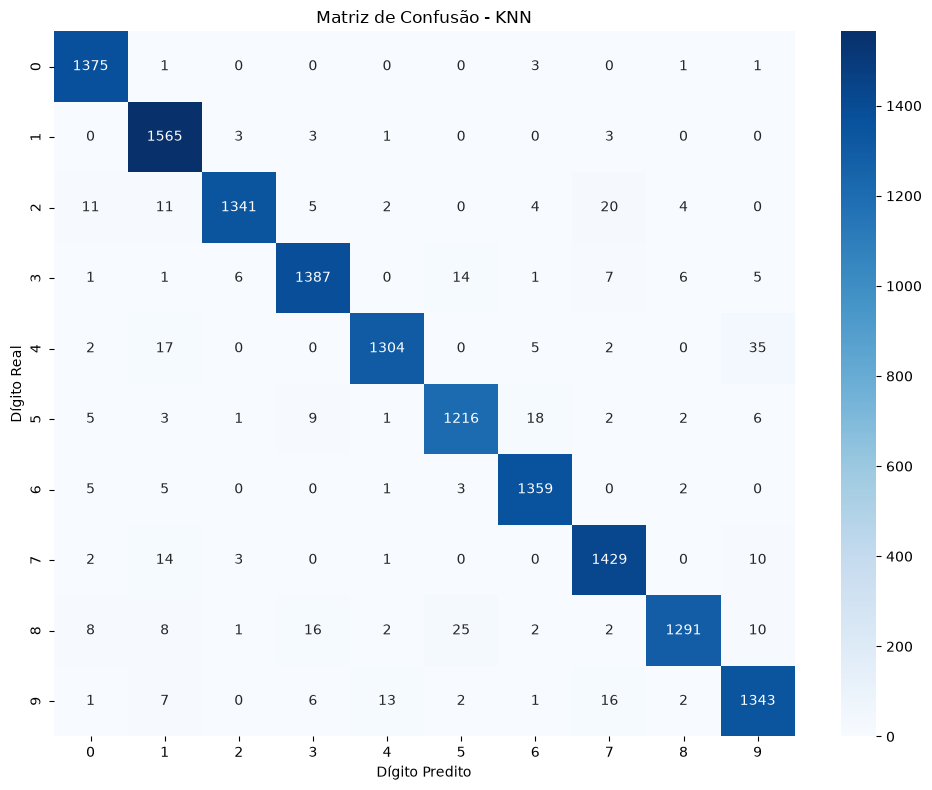

In [42]:
plotar_matriz_confusao(
    matriz_knn,
    "KNN"
)

In [43]:
maior_confusao_knn = identificar_maior_confusao(
    matriz_knn
)

print("Maior confusão do KNN:")
print(f"Dígito real: {maior_confusao_knn['digito_real']}")
print(f"Dígito predito: {maior_confusao_knn['digito_predito']}")
print(f"Quantidade de erros: {maior_confusao_knn['quantidade']}")

Maior confusão do KNN:
Dígito real: 4
Dígito predito: 9
Quantidade de erros: 35


### **Resultados da Avaliação do KNN**

Após a seleção da configuração final na etapa de validação, o KNN foi treinado novamente utilizando `n_neighbors=3` e `weights="distance"`. O modelo foi então avaliado sobre o conjunto de teste independente, que não foi utilizado durante o processo de seleção dos hiperparâmetros.

Os resultados obtidos foram:

* **Acurácia:** 97,21%;
* **Precisão ponderada:** 97,24%;
* **Recall ponderado:** 97,21%;
* **F1-score ponderado:** 97,21%;
* **Tempo de treinamento:** 0,48 segundos;
* **Tempo de predição:** 169,30 segundos.

A matriz de confusão apresentou uma dimensão de 10x10, permitindo analisar os acertos e erros de classificação entre todos os dígitos do MNIST.

O maior erro de classificação encontrado foi entre os dígitos **4 e 9**, com **35 imagens que pertenciam à classe 4 sendo classificadas como 9**.

A diferença entre a acurácia obtida no conjunto de validação na Fase 3 (97,23%) e a obtida no conjunto de teste (97,21%) foi de apenas **0,02 ponto percentual**. Esse resultado indica que o desempenho do KNN permaneceu bastante estável ao ser avaliado em dados independentes.


### **Avaliação do Random Forest**

O Random Forest será avaliado utilizando a configuração selecionada durante a etapa de validação da Fase 3, definida com `n_estimators=300` e `max_depth=20`.

Nesta etapa, o modelo será treinado novamente utilizando o conjunto de treino e, posteriormente, realizará previsões sobre o conjunto de teste, que permaneceu separado durante as etapas anteriores.

Os resultados obtidos serão utilizados para calcular as métricas de desempenho, gerar a matriz de confusão e analisar os principais erros de classificação do modelo.

Essa avaliação permitirá verificar o desempenho do Random Forest em dados que não foram utilizados durante seu treinamento ou seleção de hiperparâmetros, proporcionando uma análise mais adequada da capacidade de generalização do modelo.


In [44]:
previsoes_rf_6, tempo_predicao_rf_6 = prever_modelo(
    modelo_rf_6,
    X_teste_normalizado
)

print(f"Tempo de predição: {tempo_predicao_rf_6:.2f} segundos")

Tempo de predição: 47.97 segundos


In [45]:
metricas_rf = calcular_metricas(
    y_teste,
    previsoes_rf_6
)

metricas_rf

{'Acurácia': 0.9660714285714286,
 'Precisão': 0.966098573000954,
 'Recall': 0.9660714285714286,
 'F1-score': 0.9660559961018856}

In [46]:
matriz_rf = gerar_matriz_confusao(
    y_teste,
    previsoes_rf_6
)

matriz_rf

array([[1369,    1,    0,    0,    1,    1,    3,    0,    5,    1],
       [   0, 1548,    8,    6,    1,    2,    3,    5,    1,    1],
       [   7,    1, 1352,    4,    6,    0,    6,   11,   10,    1],
       [   2,    1,   16, 1365,    0,   15,    3,   14,    9,    3],
       [   4,    3,    2,    0, 1307,    0,    8,    0,    3,   38],
       [   5,    3,    3,   13,    1, 1207,   12,    2,    9,    8],
       [  10,    4,    1,    0,    3,    4, 1348,    0,    5,    0],
       [   1,    8,   12,    0,    8,    0,    0, 1410,    4,   16],
       [   2,    6,    6,   11,    3,    8,    5,    0, 1302,   22],
       [   6,    8,    2,   17,   16,    3,    1,    9,   12, 1317]])

In [47]:
maior_confusao_rf = identificar_maior_confusao(
    matriz_rf
)

maior_confusao_rf

{'digito_real': 4, 'digito_predito': 9, 'quantidade': 38}

### **Matriz de Confusão do Random Forest**

A matriz de confusão abaixo apresenta a distribuição das classificações realizadas pelo Random Forest no conjunto de teste. Os valores da diagonal principal representam as classificações corretas, enquanto os valores fora da diagonal representam os erros de classificação.

A maior confusão observada foi entre os dígitos **4 e 9**, com **38 imagens pertencentes à classe 4 classificadas como 9**.


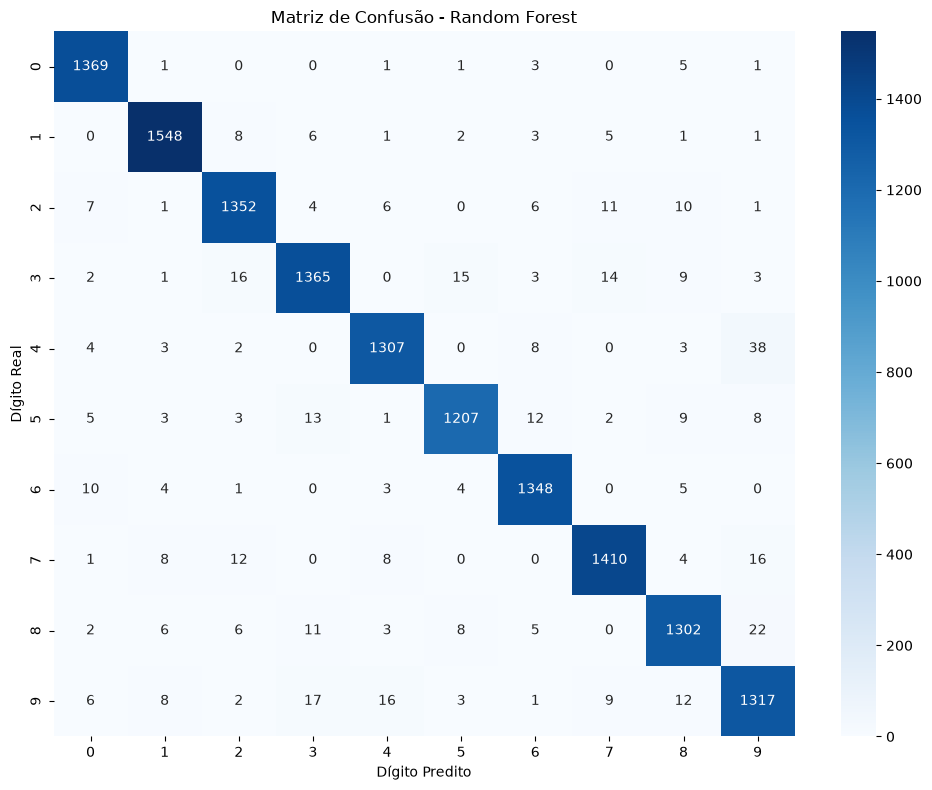

In [48]:
plotar_matriz_confusao(
    matriz_rf,
    "Random Forest"
)

### **Resultados da Avaliação do Random Forest**

Após a seleção da configuração final na etapa de validação, o Random Forest foi treinado novamente utilizando `n_estimators=300` e `max_depth=20`. O modelo foi então avaliado sobre o conjunto de teste independente, que não foi utilizado durante o processo de seleção dos hiperparâmetros.

Os resultados obtidos foram:

* **Acurácia:** 96,61%;
* **Precisão ponderada:** 96,61%;
* **Recall ponderado:** 96,61%;
* **F1-score ponderado:** 96,61%;
* **Tempo de predição:** 47,97 segundos.

A matriz de confusão apresentou uma dimensão de 10x10, permitindo analisar os acertos e erros de classificação entre todos os dígitos do MNIST.

O maior erro de classificação encontrado foi entre os dígitos **4 e 9**, com **38 imagens que pertenciam à classe 4 sendo classificadas como 9**.

A diferença entre a acurácia obtida no conjunto de validação na Fase 3 (96,71%) e a obtida no conjunto de teste (96,61%) foi de apenas **0,10 ponto percentual**. Esse resultado indica que o desempenho do Random Forest permaneceu bastante estável ao ser avaliado em dados independentes.


### **Avaliação do MLP**

O Multi-Layer Perceptron (MLP) será avaliado utilizando a configuração selecionada durante a etapa de validação da Fase 3, definida com `hidden_layer_sizes=(30,)` e `learning_rate_init=0.001`.

Nesta etapa, o modelo será treinado novamente utilizando o conjunto de treino e, posteriormente, realizará previsões sobre o conjunto de teste, que permaneceu separado durante as etapas anteriores.

Os resultados obtidos serão utilizados para calcular as métricas de desempenho, gerar a matriz de confusão e analisar os principais erros de classificação do modelo.

Essa avaliação permitirá verificar o desempenho do MLP em dados que não foram utilizados durante seu treinamento ou seleção de hiperparâmetros, proporcionando uma análise mais adequada da capacidade de generalização do modelo.


In [49]:
previsoes_mlp_5, tempo_predicao_mlp_5 = prever_modelo(
    modelo_mlp_5,
    X_teste_normalizado
)

print(f"Tempo de predição: {tempo_predicao_mlp_5:.2f} segundos")

Tempo de predição: 3.01 segundos


In [50]:
metricas_mlp = calcular_metricas(
    y_teste,
    previsoes_mlp_5
)

metricas_mlp

{'Acurácia': 0.9620714285714286,
 'Precisão': 0.9621164731505769,
 'Recall': 0.9620714285714286,
 'F1-score': 0.9620646166500392}

In [51]:
matriz_mlp = gerar_matriz_confusao(
    y_teste,
    previsoes_mlp_5
)

matriz_mlp

array([[1357,    0,    5,    1,    1,    2,    4,    0,    6,    5],
       [   0, 1552,    6,    2,    0,    1,    1,    5,    7,    1],
       [   8,    8, 1338,   10,    5,    1,    5,    8,   11,    4],
       [   1,    3,   13, 1356,    0,   27,    2,    8,   15,    3],
       [   1,    4,    3,    3, 1295,    1,   11,    3,    9,   35],
       [   5,    2,    2,   12,    3, 1207,   12,    0,   11,    9],
       [   7,    2,    6,    1,    5,    8, 1342,    0,    4,    0],
       [   2,    3,    7,    7,    9,    3,    0, 1401,    4,   23],
       [   9,   11,    7,   12,    2,    7,    4,    5, 1297,   11],
       [   4,    5,    2,   10,   15,    5,    0,   17,    9, 1324]])

In [52]:
maior_confusao_mlp = identificar_maior_confusao(
    matriz_mlp
)

maior_confusao_mlp

{'digito_real': 4, 'digito_predito': 9, 'quantidade': 35}

### **Matriz de Confusão do MLP**

A matriz de confusão abaixo apresenta a distribuição das classificações realizadas pelo MLP no conjunto de teste. Os valores da diagonal principal representam as classificações corretas, enquanto os valores fora da diagonal representam os erros de classificação.

A maior confusão observada foi entre os dígitos **4 e 9**, com **35 imagens pertencentes à classe 4 classificadas como 9**.


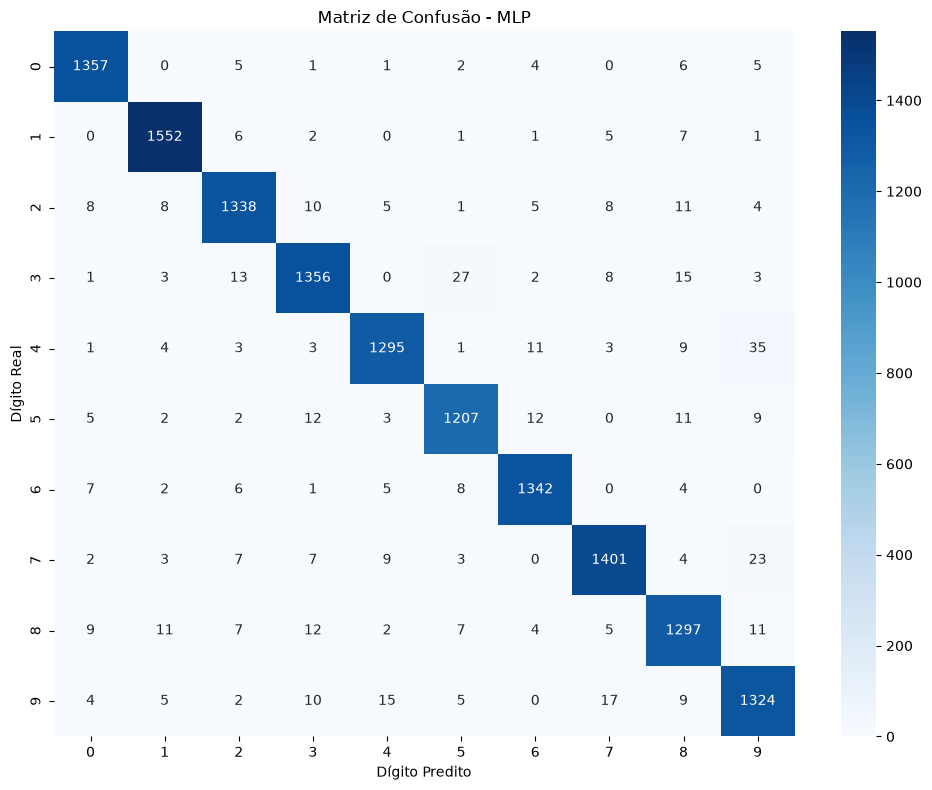

In [53]:
plotar_matriz_confusao(
    matriz_mlp,
    "MLP"
)

### **Resultados da Avaliação do MLP**

Após a seleção da configuração final na etapa de validação, o MLP foi treinado novamente utilizando `hidden_layer_sizes=(30,)` e `learning_rate_init=0.001`. O modelo foi então avaliado sobre o conjunto de teste independente, que não foi utilizado durante o processo de seleção dos hiperparâmetros.

Os resultados obtidos foram:

* **Acurácia:** 96,21%;
* **Precisão ponderada:** 96,21%;
* **Recall ponderado:** 96,21%;
* **F1-score ponderado:** 96,21%;
* **Tempo de predição:** 3,01 segundos.

A matriz de confusão apresentou uma dimensão de 10x10, permitindo analisar os acertos e erros de classificação entre todos os dígitos do MNIST.

O maior erro de classificação encontrado foi entre os dígitos **4 e 9**, com **35 imagens que pertenciam à classe 4 sendo classificadas como 9**.

A diferença entre a acurácia obtida no conjunto de validação na Fase 3 (96,13%) e a obtida no conjunto de teste (96,21%) foi de **0,08 ponto percentual**. Esse resultado indica que o desempenho do MLP permaneceu bastante estável ao ser avaliado em dados independentes.



### **Comparação dos Modelos**

Após a avaliação individual dos três modelos no conjunto de teste, os resultados foram consolidados para permitir uma comparação direta entre seus desempenhos.

A comparação considera as métricas de **Acurácia, Precisão, Recall e F1-score ponderados**, além do **tempo de predição**, permitindo analisar não apenas a capacidade de classificação dos modelos, mas também o custo computacional associado às previsões.

A tabela a seguir apresenta os resultados consolidados dos modelos KNN, Random Forest e MLP.


In [54]:
comparacao_modelos = pd.DataFrame({
    "Modelo": ["KNN", "Random Forest", "MLP"],
    "Acurácia": [
        metricas_knn["Acurácia"],
        metricas_rf["Acurácia"],
        metricas_mlp["Acurácia"]
    ],
    "Precisão": [
        metricas_knn["Precisão"],
        metricas_rf["Precisão"],
        metricas_mlp["Precisão"]
    ],
    "Recall": [
        metricas_knn["Recall"],
        metricas_rf["Recall"],
        metricas_mlp["Recall"]
    ],
    "F1-score": [
        metricas_knn["F1-score"],
        metricas_rf["F1-score"],
        metricas_mlp["F1-score"]
    ],
    "Tempo de treinamento (s)": [
        tempo_treinamento_knn,
        tempo_treinamento_rf_6,
        tempo_treinamento_mlp_5
    ],
    "Tempo de predição (s)": [
        tempo_predicao_knn,
        tempo_predicao_rf_6,
        tempo_predicao_mlp_5
    ]
})

comparacao_modelos

,Modelo,Acurácia,Precisão,Recall,F1-score,Tempo de treinamento (s),Tempo de predição (s)
0,KNN,0.972143,0.972371,0.972143,0.972110,0.479327,169.299640
1,Random Forest,0.966071,0.966099,0.966071,0.966056,285.574590,47.967150
2,MLP,0.962071,0.962116,0.962071,0.962065,895.515641,3.014858


In [55]:
comparacao_formatada = comparacao_modelos.copy()

colunas_metricas = [
    "Acurácia",
    "Precisão",
    "Recall",
    "F1-score"
]

for coluna in colunas_metricas:
    comparacao_formatada[coluna] = (
        comparacao_formatada[coluna] * 100
    ).round(2).astype(str) + "%"

comparacao_formatada["Tempo de treinamento (s)"] = (
    comparacao_formatada["Tempo de treinamento (s)"].round(2)
)

comparacao_formatada["Tempo de predição (s)"] = (
    comparacao_formatada["Tempo de predição (s)"].round(2)
)

comparacao_formatada

,Modelo,Acurácia,Precisão,Recall,F1-score,Tempo de treinamento (s),Tempo de predição (s)
0,KNN,97.21%,97.24%,97.21%,97.21%,0.48,169.30
1,Random Forest,96.61%,96.61%,96.61%,96.61%,285.57,47.97
2,MLP,96.21%,96.21%,96.21%,96.21%,895.52,3.01


### **Análise Comparativa dos Modelos**

A comparação dos três modelos foi realizada utilizando os resultados obtidos no conjunto de teste independente.

As métricas de Acurácia, Precisão, Recall e F1-score apresentaram valores próximos entre si para cada modelo, permitindo uma comparação consistente do desempenho de classificação.

Além das métricas de desempenho, também foram considerados os tempos de treinamento e de predição para analisar o custo computacional dos modelos.

O **KNN** apresentou o melhor desempenho geral, alcançando **97,21% de acurácia**, **97,24% de precisão**, **97,21% de recall** e **97,21% de F1-score**.

Seu tempo de treinamento foi de apenas **0,48 segundos**, o menor entre os três modelos.

Entretanto, apresentou o maior tempo de predição, de **169,30 segundos**, devido à característica do algoritmo de realizar as comparações com as amostras durante a etapa de predição.

O **Random Forest** apresentou **96,61% de acurácia**, **96,61% de precisão**, **96,61% de recall** e **96,61% de F1-score**.

Seu tempo de treinamento foi de **285,57 segundos**, enquanto o tempo de predição foi de **47,97 segundos**.

Apesar de apresentar uma acurácia aproximadamente **0,60 ponto percentual inferior** à do KNN, apresentou um tempo de predição significativamente menor.

O **MLP** apresentou **96,21% de acurácia**, **96,21% de precisão**, **96,21% de recall** e **96,21% de F1-score**.

Foi o modelo que apresentou o maior tempo de treinamento, com **895,52 segundos**, mas apresentou o menor tempo de predição, de apenas **3,01 segundos**. Portanto, embora tenha exigido maior custo computacional durante o treinamento, apresentou maior eficiência na etapa de classificação das amostras de teste.

Em relação aos erros de classificação, os três modelos apresentaram a maior confusão entre os dígitos **4 e 9**.

O KNN e o MLP classificaram **35 imagens da classe 4 como 9**, enquanto o Random Forest apresentou **38 ocorrências** dessa confusão.

A recorrência desse erro nos três modelos indica que a distinção entre esses dígitos representa uma dificuldade comum no conjunto de dados, independentemente do algoritmo utilizado.

Considerando conjuntamente o desempenho e o custo computacional, o **KNN apresentou a maior acurácia e o menor tempo de treinamento**, mas apresentou o maior tempo de predição. O **MLP**, apesar do maior tempo de treinamento, apresentou o menor tempo de predição. O **Random Forest** apresentou valores intermediários de desempenho e tempo de predição, além de um tempo de treinamento inferior ao MLP.

Dessa forma, considerando exclusivamente a capacidade de classificação, o **KNN foi o modelo de melhor desempenho**, com **97,21% de acurácia**.

Entretanto, a escolha do modelo deve considerar também o contexto de utilização e o custo computacional das diferentes etapas.

Para aplicações em que o modelo será treinado poucas vezes e utilizado para realizar muitas previsões, o **MLP pode apresentar uma vantagem devido ao seu baixo tempo de predição**, apesar do maior custo de treinamento.

Para o objetivo deste projeto, o **KNN é considerado o modelo de melhor desempenho preditivo entre os três avaliados**.


### **Conclusão da Fase 4**

A avaliação realizada sobre o conjunto de teste independente permitiu comparar o desempenho dos modelos KNN, Random Forest e MLP, considerando tanto as métricas de classificação quanto o custo computacional relacionado aos tempos de treinamento e predição.

Entre os modelos avaliados, o **KNN apresentou o melhor desempenho de classificação**, alcançando **97,21% de acurácia**, **97,24% de precisão**, **97,21% de recall** e **97,21% de F1-score**.

Além disso, apresentou o menor tempo de treinamento, de apenas **0,48 segundos**.

Entretanto, apresentou o maior tempo de predição, de **169,30 segundos**.

O **Random Forest** apresentou **96,61% de acurácia**, com tempo de treinamento de **285,57 segundos** e tempo de predição de **47,97 segundos**.

O **MLP** apresentou **96,21% de acurácia**, sendo o modelo com maior tempo de treinamento, de **895,52 segundos**, mas apresentou o menor tempo de predição, de apenas **3,01 segundos**.

As matrizes de confusão mostraram um padrão consistente de erro entre os três modelos. A principal confusão ocorreu entre os dígitos **4 e 9**, sendo essa a maior ocorrência de erro identificada nas matrizes analisadas. O KNN e o MLP apresentaram **35 ocorrências** dessa confusão, enquanto o Random Forest apresentou **38 ocorrências**.

Considerando conjuntamente o desempenho e o custo computacional, o **KNN apresentou a maior acurácia e o menor tempo de treinamento**, mas possui um custo elevado na etapa de predição.

O **MLP apresentou o menor tempo de predição**, apesar de exigir o maior tempo de treinamento. Já o **Random Forest apresentou valores intermediários de desempenho e tempo de predição**, além de um tempo de treinamento inferior ao MLP.

Dessa forma, considerando o objetivo principal de obter o melhor desempenho de classificação no conjunto de teste, o **KNN foi o modelo de melhor desempenho entre os três avaliados**, alcançando **97,21% de acurácia**.

A análise dos tempos de treinamento e predição também mostrou que a escolha de um modelo de aprendizado de máquina deve considerar não apenas a acurácia, mas também o custo computacional associado ao contexto de utilização.

Os resultados obtidos nesta etapa serão utilizados como referência para os experimentos de **robustez e generalização da Fase 5**, nos quais será analisado o comportamento do modelo diante de classes não observadas durante o treinamento e de imagens manuscritas próprias.


In [56]:

pasta_modelos = Path("../modelos")
pasta_modelos.mkdir(parents=True, exist_ok=True)

joblib.dump(knn, pasta_modelos / "knn.pkl")
joblib.dump(modelo_rf_6, pasta_modelos / "random_forest.pkl")
joblib.dump(modelo_mlp_5, pasta_modelos / "mlp.pkl")

print("Modelos salvos com sucesso!")

Modelos salvos com sucesso!


In [57]:
list(pasta_modelos.iterdir())

[WindowsPath('../modelos/knn.pkl'),
 WindowsPath('../modelos/mlp.pkl'),
 WindowsPath('../modelos/random_forest.pkl'),
 WindowsPath('../modelos/random_forest_class_masking.pkl')]

## **Fase 5 - Robustez e Generalização**

Nesta etapa será avaliada a capacidade de generalização dos modelos diante de classes que não foram apresentadas durante o treinamento, além de verificar o comportamento do melhor modelo desenvolvido sobre imagens manuscritas próprias.

Serão executadas as seguintes ações:

* Seleção de duas classes do conjunto de dados para serem completamente removidas do treinamento;

* Treinamento de um modelo sem que ele tenha acesso a nenhuma amostra das classes selecionadas;

* Avaliação do modelo sobre um conjunto de teste composto exclusivamente pelas classes que permaneceram ocultas durante o treinamento;

* Análise das previsões realizadas pelo modelo sobre as classes nunca vistas, incluindo a distribuição das classes preditas e a geração de uma matriz de confusão;

* Análise das probabilidades produzidas pelo modelo para investigar possíveis situações de **falsa certeza (overconfidence)** diante de dados pertencentes a classes desconhecidas;

* Construção de um pipeline de pré-processamento para imagens manuscritas próprias, incluindo conversão para escala de cinza, inversão de cores, centralização, redimensionamento e normalização;

* Realização de previsões sobre as imagens próprias utilizando o melhor modelo identificado na avaliação comparativa;

* Visualização das imagens processadas juntamente com as probabilidades atribuídas pelo modelo às diferentes classes;

* Análise dos resultados obtidos, discutindo as limitações de generalização dos modelos e a diferença entre dados semelhantes aos utilizados no treinamento e dados não observados anteriormente.


### **5.1 - Class Masking**

Nesta etapa será realizado um experimento de **Class Masking**, no qual duas classes do conjunto de treinamento serão completamente removidas antes do treinamento do modelo.

O objetivo é avaliar como um classificador se comporta quando recebe, durante a etapa de teste, exemplos pertencentes a classes que nunca foram apresentadas durante seu treinamento.

Para este experimento, serão ocultadas as classes **4 e 7**, enquanto as demais classes permanecerão disponíveis para o treinamento.

Serão executadas as seguintes ações:

* Seleção das classes 4 e 7 como classes a serem ocultadas;

* Remoção de todas as amostras dessas classes do conjunto de treinamento;

* Verificação das classes restantes após o processo de filtragem;

* Treinamento de um modelo Random Forest utilizando somente as classes conhecidas;

* Verificação das classes efetivamente aprendidas pelo modelo, garantindo que as classes 4 e 7 não estejam presentes no treinamento;

* Registro do tempo de treinamento do modelo para posterior análise do custo computacional;

* Salvamento do modelo treinado para que ele possa ser utilizado posteriormente na avaliação de generalização extrema da seção 5.2.


In [58]:
classes_ocultadas = np.array(["4", "7"])

In [59]:
X_treino_masked, y_treino_masked = remover_classes_treinamento(
    X_treino_normalizado,
    y_treino,
    classes_ocultadas
)

In [60]:
print("Dimensão original:", X_treino_normalizado.shape)
print("Dimensão após masking:", X_treino_masked.shape)

print("\nClasses originais:")
print(verificar_classes(y_treino))

print("\nClasses após masking:")
print(verificar_classes(y_treino_masked))

Dimensão original: (49000, 784)
Dimensão após masking: (39118, 784)

Classes originais:
['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']

Classes após masking:
['0' '1' '2' '3' '5' '6' '8' '9']


In [61]:
X_ood, y_ood = selecionar_classes_teste(
    X_teste_normalizado,
    y_teste,
    classes_ocultadas
)

In [62]:
print("Dimensão do conjunto OOD:", X_ood.shape)

print("\nClasses presentes no OOD:")
print(verificar_classes(y_ood))

print("\nQuantidade por classe:")
print(np.unique(y_ood, return_counts=True))

Dimensão do conjunto OOD: (2824, 784)

Classes presentes no OOD:
['4' '7']

Quantidade por classe:
(array(['4', '7'], dtype=object), array([1365, 1459]))


In [63]:
modelo_rf_masked = criar_random_forest(
    n_estimators=300,
    max_depth=20
)

modelo_rf_masked, tempo_treinamento_masked = treinar_modelo(
    modelo_rf_masked,
    X_treino_masked,
    y_treino_masked
)

print(
    f"Tempo de treinamento: "
    f"{tempo_treinamento_masked:.2f} segundos"
)

Tempo de treinamento: 223.56 segundos


In [64]:
print("Classes aprendidas pelo modelo:")
print(modelo_rf_masked.classes_)

Classes aprendidas pelo modelo:
['0' '1' '2' '3' '5' '6' '8' '9']


In [65]:

pasta_modelos = Path("../modelos")

pasta_modelos.mkdir(parents=True, exist_ok=True)

joblib.dump(
    modelo_rf_masked,
    pasta_modelos / "random_forest_class_masking.pkl"
)

print("Modelo de Class Masking salvo com sucesso!")

Modelo de Class Masking salvo com sucesso!


In [66]:
print("Classes ocultadas:", classes_ocultadas)
print("Classes presentes no treinamento:", verificar_classes(y_treino_masked))
print("Classes aprendidas pelo modelo:", modelo_rf_masked.classes_)

Classes ocultadas: ['4' '7']
Classes presentes no treinamento: ['0' '1' '2' '3' '5' '6' '8' '9']
Classes aprendidas pelo modelo: ['0' '1' '2' '3' '5' '6' '8' '9']


### **Conclusão**

O experimento de Class Masking foi realizado com sucesso, removendo completamente as classes **4 e 7** do conjunto de treinamento.

Após a filtragem, o conjunto utilizado para o treinamento passou de **49.000 para 39.118 amostras**, permanecendo apenas as classes 0, 1, 2, 3, 5, 6, 8 e 9.

O modelo **Random Forest**, configurado com 300 árvores e profundidade máxima de 20, foi treinado exclusivamente com essas oito classes.

A verificação das classes aprendidas confirmou que os dígitos 4 e 7 não foram apresentados ao modelo durante o treinamento. As classes aprendidas foram **0, 1, 2, 3, 5, 6, 8 e 9**, correspondendo exatamente às classes presentes no conjunto de treinamento após a remoção.

O treinamento foi concluído em **223,56 segundos**.

O modelo resultante foi salvo para ser utilizado na próxima etapa, mantendo as mesmas condições experimentais.

Dessa forma, a etapa 5.1 estabelece um cenário controlado para avaliar, na etapa 5.2, como o classificador reage ao receber exemplos pertencentes a classes completamente desconhecidas durante seu treinamento.


### **5.2 - Extreme Generalization / OOD**

Nesta etapa será avaliada a capacidade de generalização do modelo treinado na etapa anterior diante de classes que não foram apresentadas durante o treinamento.

O modelo Random Forest treinado na etapa 5.1, que teve as classes 4 e 7 completamente removidas do treinamento, será submetido exclusivamente a amostras dessas duas classes. O objetivo é observar como o classificador reage quando recebe dados pertencentes a classes que não fazem parte do conjunto de classes conhecidas.

Serão executadas as seguintes ações:

* Utilização do modelo treinado na etapa 5.1, sem realizar um novo treinamento;

* Utilização de um conjunto de teste contendo exclusivamente as classes ocultadas 4 e 7;

* Realização das previsões do modelo sobre as classes nunca vistas durante o treinamento;

* Análise da distribuição das classes conhecidas atribuídas pelo classificador aos dígitos 4 e 7;

* Geração de uma matriz de confusão para visualizar como as classes ocultadas são associadas às classes conhecidas;

* Obtenção das probabilidades previstas pelo modelo para analisar seu nível de confiança;

* Investigação de possíveis situações de falsa certeza (overconfidence), verificando se o modelo apresenta probabilidades elevadas mesmo diante de classes que nunca foram observadas no treinamento;

* Interpretação dos resultados e discussão das limitações do modelo diante de dados pertencentes a classes desconhecidas.


In [67]:
previsoes_ood, tempo_predicao_ood = prever_modelo(
    modelo_rf_masked,
    X_ood
)

print(f"Tempo de predição OOD: {tempo_predicao_ood:.2f} segundos")

Tempo de predição OOD: 4.87 segundos


In [68]:
resultados_ood = analisar_previsoes_ood(
    y_ood,
    previsoes_ood
)

resultados_ood

{'4': {'0': {'quantidade': 6, 'percentual': 0.43956043956043955},
  '1': {'quantidade': 6, 'percentual': 0.43956043956043955},
  '2': {'quantidade': 16, 'percentual': 1.1721611721611722},
  '3': {'quantidade': 1, 'percentual': 0.07326007326007326},
  '6': {'quantidade': 33, 'percentual': 2.417582417582418},
  '8': {'quantidade': 32, 'percentual': 2.3443223443223444},
  '9': {'quantidade': 1271, 'percentual': 93.11355311355311}},
 '7': {'0': {'quantidade': 33, 'percentual': 2.2618231665524333},
  '1': {'quantidade': 25, 'percentual': 1.7135023989033584},
  '2': {'quantidade': 234, 'percentual': 16.038382453735437},
  '3': {'quantidade': 52, 'percentual': 3.564084989718986},
  '5': {'quantidade': 10, 'percentual': 0.6854009595613434},
  '8': {'quantidade': 24, 'percentual': 1.644962302947224},
  '9': {'quantidade': 1081, 'percentual': 74.09184372858122}}}

In [69]:
classes_preditas_ood = modelo_rf_masked.classes_

matriz_ood = calcular_matriz_confusao_ood(
    y_ood,
    previsoes_ood,
    classes_ocultadas,
    classes_preditas_ood
)

print(matriz_ood)

[[   6    6   16    1    0   33   32 1271]
 [  33   25  234   52   10    0   24 1081]]


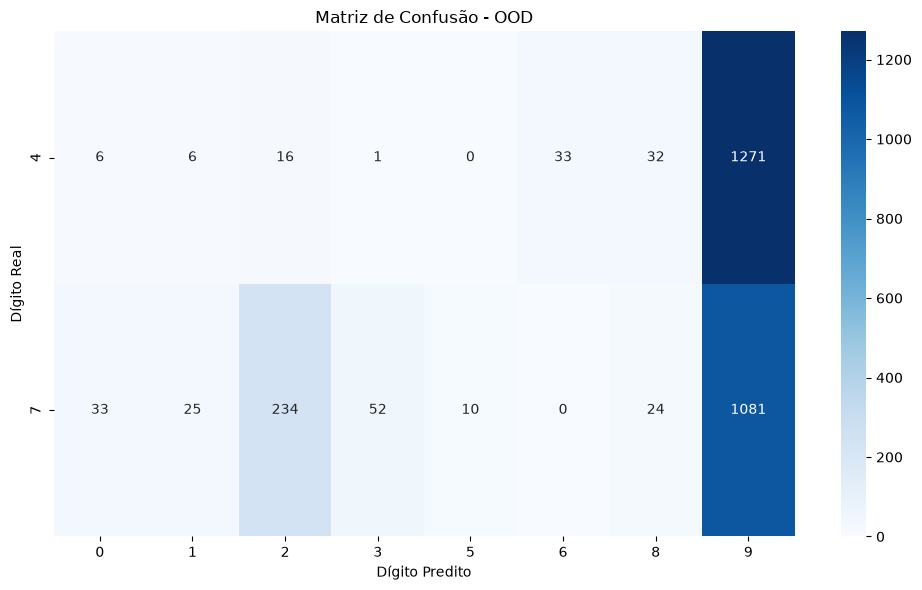

In [70]:
plotar_matriz_confusao_ood(
    matriz_ood,
    classes_ocultadas,
    classes_preditas_ood
)

In [71]:
probabilidades_ood = obter_probabilidades(
    modelo_rf_masked,
    X_ood
)

print("Formato das probabilidades:", probabilidades_ood.shape)

Formato das probabilidades: (2824, 8)


In [72]:
confiancas_ood = probabilidades_ood.max(axis=1)

print(f"Confiança média: {confiancas_ood.mean():.4f}")
print(f"Confiança mínima: {confiancas_ood.min():.4f}")
print(f"Confiança máxima: {confiancas_ood.max():.4f}")

Confiança média: 0.5672
Confiança mínima: 0.1711
Confiança máxima: 0.9816


In [73]:
resultados_confianca_ood = analisar_confianca_ood(
    probabilidades_ood,
    y_ood
)

resultados_confianca_ood

{'4': {'confianca_media': 0.5844210240905124,
  'confianca_minima': 0.17111111111111113,
  'confianca_maxima': 0.9816398533929466},
 '7': {'confianca_media': 0.5510503883439256,
  'confianca_minima': 0.21232168731139725,
  'confianca_maxima': 0.9746797039129188}}

In [74]:
resultados_limiares_ood = contar_confiancas_ood(
    probabilidades_ood,
    y_ood
)

resultados_limiares_ood

{'4': {'>=80%': {'quantidade': 138, 'percentual': 10.10989010989011},
  '>=90%': {'quantidade': 45, 'percentual': 3.296703296703297},
  '>=95%': {'quantidade': 6, 'percentual': 0.43956043956043955}},
 '7': {'>=80%': {'quantidade': 193, 'percentual': 13.228238519533928},
  '>=90%': {'quantidade': 50, 'percentual': 3.427004797806717},
  '>=95%': {'quantidade': 15, 'percentual': 1.0281014393420151}}}

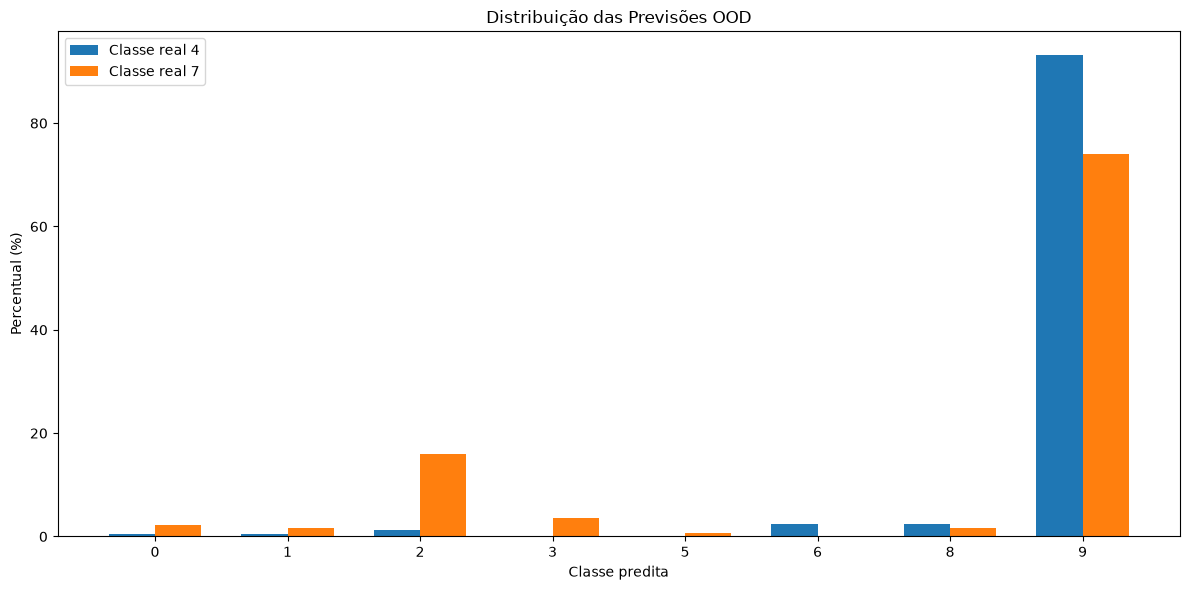

Gráfico salvo em: C:\Users\franc\OneDrive\Desktop\Projetos\Curso\MNIST_Classification\imagens\ood\distribuicao_previsoes_ood.png


In [75]:
caminho_grafico_ood = plotar_distribuicao_previsoes_ood(
    resultados_ood
)

print(f"Gráfico salvo em: {caminho_grafico_ood}")

### **Análise dos Resultados**

O experimento de generalização extrema foi realizado utilizando o modelo **Random Forest treinado na etapa 5.1**, sem qualquer amostra das classes **4 e 7** durante o treinamento.

O tempo necessário para realizar as previsões sobre o conjunto OOD foi de **4,87 segundos**.

O conjunto utilizado nesta avaliação foi composto exclusivamente por essas duas classes, totalizando **2.824 imagens**, sendo 1.365 da classe 4 e 1.459 da classe 7.

Como as classes 4 e 7 não fazem parte das classes conhecidas pelo modelo, o classificador não possui essas categorias entre suas possíveis saídas.

Dessa forma, as imagens foram obrigatoriamente associadas a uma das classes conhecidas: **0, 1, 2, 3, 5, 6, 8 ou 9**.

#### **Comportamento das previsões**

A análise da distribuição das previsões mostrou uma forte tendência do modelo em classificar as duas classes ocultadas como o dígito **9**.

Para as imagens cujo dígito real era **4**, foram realizadas **1.271 previsões como 9**, correspondendo a **93,11%** dos exemplos.

As demais previsões foram distribuídas principalmente entre as classes 6, com 2,42%, e 8, com 2,34%.

Para as imagens cujo dígito real era **7**, o modelo também apresentou forte preferência pela classe 9.

Foram **1.081 previsões como 9**, correspondendo a **74,09%** dos exemplos.

A segunda maior concentração ocorreu na classe 2, com **16,04%** das previsões.

Esse comportamento indica que, diante de exemplos pertencentes a classes que não foram aprendidas, o modelo não identifica a ausência dessas classes.

Em vez disso, ele procura representar os exemplos utilizando uma das categorias disponíveis no treinamento.

#### **Matriz de confusão**

A matriz de confusão evidencia esse comportamento de forma mais clara.

A maior concentração de previsões ocorreu na coluna correspondente ao dígito **9**, tanto para os exemplos reais da classe 4 quanto para os exemplos reais da classe 7.

Esse resultado é especialmente relevante porque, na avaliação realizada na **Fase 4**, a principal confusão do modelo também estava relacionada à classificação do dígito **4 como 9**.

No experimento com classes ocultadas, essa tendência tornou-se muito mais acentuada, chegando a representar **93,11%** das imagens reais da classe 4.

Para a classe 7, apesar de a associação com o dígito 9 também ter predominado, houve uma quantidade significativa de previsões como 2.

Isso demonstra que o modelo utiliza diferentes padrões visuais aprendidos nas classes conhecidas para representar as imagens desconhecidas.

#### **Falsa certeza (Overconfidence)**

A análise das probabilidades demonstra que o modelo pode apresentar níveis elevados de confiança mesmo quando recebe imagens de classes que nunca foram apresentadas durante o treinamento.

A confiança média foi de **58,44%** para as imagens da classe 4 e **55,11%** para as imagens da classe 7.

Entretanto, algumas amostras apresentaram valores muito superiores: a maior confiança observada foi de **98,16%** para uma imagem da classe 4 e **97,47%** para uma imagem da classe 7.

Além disso, **10,11%** das imagens da classe 4 e **13,23%** das imagens da classe 7 receberam confiança de pelo menos 80%.

Também foram observadas previsões com confiança superior a 95%, embora essas classes fossem completamente desconhecidas pelo modelo.

Esse resultado caracteriza um cenário de **falsa certeza**: o modelo pode produzir uma probabilidade elevada para uma classe conhecida mesmo quando a entrada pertence a uma classe que não fazia parte do conjunto de treinamento.

Portanto, uma alta probabilidade de previsão não significa necessariamente que o modelo reconheceu corretamente o objeto ou que a entrada pertence ao domínio conhecido.


#### **Conclusão da etapa 5.2**

O experimento demonstrou que o modelo **Random Forest não consegue identificar diretamente que as classes 4 e 7 são desconhecidas**, pois essas categorias não fazem parte do espaço de saída aprendido durante o treinamento.

Em consequência, as imagens são forçadas a receber uma das classes conhecidas.

A forte concentração das previsões no dígito 9 demonstra que o modelo tende a utilizar padrões previamente aprendidos para representar dados que não pertencem às classes conhecidas.

Além disso, os altos níveis de confiança observados em algumas previsões evidenciam o problema de **overconfidence em dados não observados**.

Portanto, o experimento confirma uma limitação importante de classificadores supervisionados tradicionais: **uma previsão com alta confiança não garante que o modelo tenha conhecimento suficiente sobre a entrada**, especialmente quando são apresentados dados pertencentes a classes que não estavam disponíveis durante o treinamento.


In [76]:
caminho_imagem = "../imagens/minhas_imagens/0.jpg"

imagem_processada, imagem_normalizada, imagem_modelo = preprocessar_imagem(
    caminho_imagem
)

print("Dimensão da imagem processada:", imagem_processada.size)
print("Dimensão da imagem normalizada:", imagem_normalizada.shape)
print("Dimensão da entrada do modelo:", imagem_modelo.shape)
print("Valor mínimo:", imagem_normalizada.min())
print("Valor máximo:", imagem_normalizada.max())

Dimensão da imagem processada: (28, 28)
Dimensão da imagem normalizada: (28, 28)
Dimensão da entrada do modelo: (1, 784)
Valor mínimo: 0.0
Valor máximo: 0.52156866


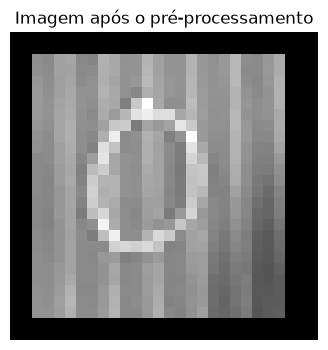

In [77]:
plt.figure(figsize=(4, 4))
plt.imshow(imagem_processada, cmap="gray")
plt.title("Imagem após o pré-processamento")
plt.axis("off")
plt.show()

In [78]:
modelo_knn = joblib.load("../modelos/knn.pkl")

print("KNN carregado com sucesso!")

KNN carregado com sucesso!


In [79]:
digito_predito, probabilidades = prever_imagem(
    modelo_knn,
    imagem_modelo
)

print("Dígito real: 0")
print("Dígito predito:", digito_predito)

Dígito real: 0
Dígito predito: 4


In [80]:
for classe, probabilidade in zip(
    modelo_knn.classes_,
    probabilidades
):
    print(
        f"Dígito {classe}: "
        f"{probabilidade:.2%}"
    )

Dígito 0: 0.00%
Dígito 1: 33.24%
Dígito 2: 0.00%
Dígito 3: 0.00%
Dígito 4: 66.76%
Dígito 5: 0.00%
Dígito 6: 0.00%
Dígito 7: 0.00%
Dígito 8: 0.00%
Dígito 9: 0.00%


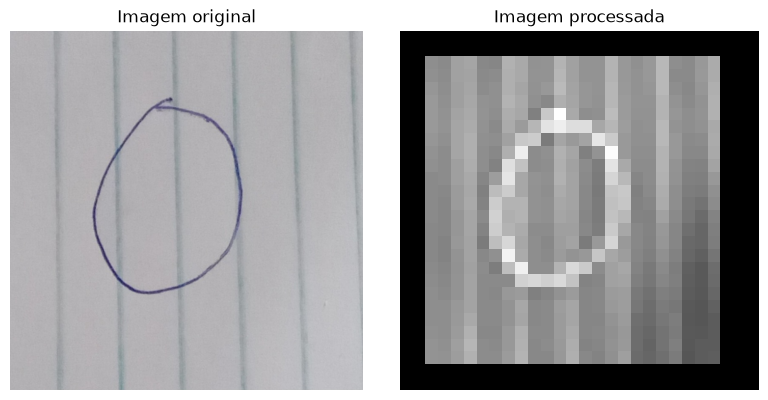

In [81]:
fig, eixos = plt.subplots(1, 2, figsize=(8, 4))

eixos[0].imshow(
    carregar_imagem(caminho_imagem)
)
eixos[0].set_title("Imagem original")
eixos[0].axis("off")

eixos[1].imshow(
    imagem_normalizada,
    cmap="gray"
)
eixos[1].set_title("Imagem processada")
eixos[1].axis("off")

plt.tight_layout()
plt.show()

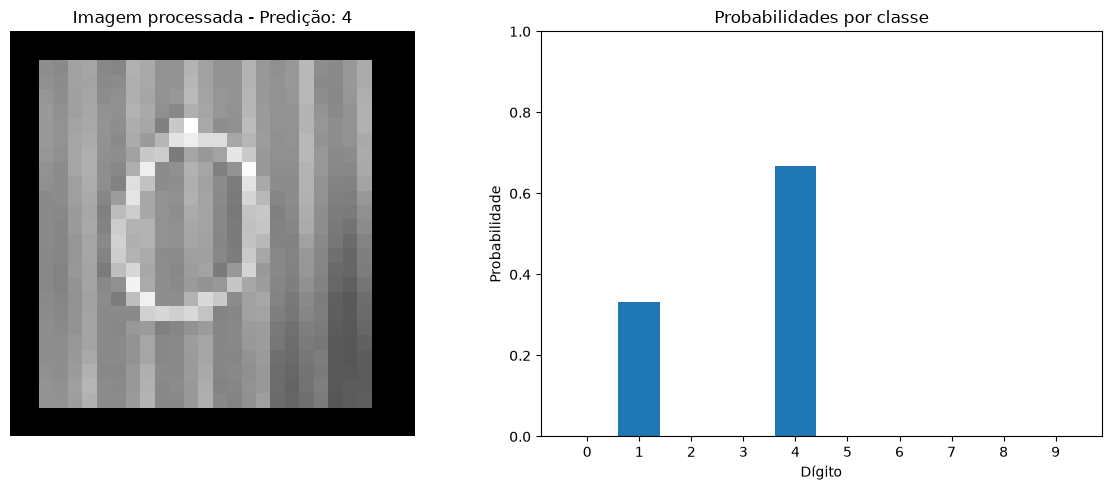

In [82]:
plotar_previsao(
    imagem_processada,
    digito_predito,
    probabilidades,
    modelo_knn.classes_
)

In [83]:
pasta_imagens = Path("../imagens/minhas_imagens")

resultados_imagens = []

for digito_real in range(10):
    caminho = pasta_imagens / f"{digito_real}.jpg"

    imagem_processada, imagem_normalizada, imagem_modelo = preprocessar_imagem(caminho)

    digito_predito, probabilidades = prever_imagem(
        modelo_knn,
        imagem_modelo
    )

    resultados_imagens.append({
        "digito_real": digito_real,
        "digito_predito": digito_predito,
        "acertou": digito_real == digito_predito,
        "confianca": probabilidades.max()
    })

resultados_imagens

[{'digito_real': 0,
  'digito_predito': '4',
  'acertou': False,
  'confianca': np.float64(0.6675849869210618)},
 {'digito_real': 1,
  'digito_predito': '6',
  'acertou': False,
  'confianca': np.float64(0.33745814526607154)},
 {'digito_real': 2,
  'digito_predito': '2',
  'acertou': False,
  'confianca': np.float64(0.6663099420771909)},
 {'digito_real': 3,
  'digito_predito': '4',
  'acertou': False,
  'confianca': np.float64(0.6674265775138873)},
 {'digito_real': 4,
  'digito_predito': '4',
  'acertou': False,
  'confianca': np.float64(0.6670680065501372)},
 {'digito_real': 5,
  'digito_predito': '1',
  'acertou': False,
  'confianca': np.float64(0.6691631281775594)},
 {'digito_real': 6,
  'digito_predito': '1',
  'acertou': False,
  'confianca': np.float64(1.0)},
 {'digito_real': 7,
  'digito_predito': '8',
  'acertou': False,
  'confianca': np.float64(0.33625747193180594)},
 {'digito_real': 8,
  'digito_predito': '2',
  'acertou': False,
  'confianca': np.float64(0.3337406118873504

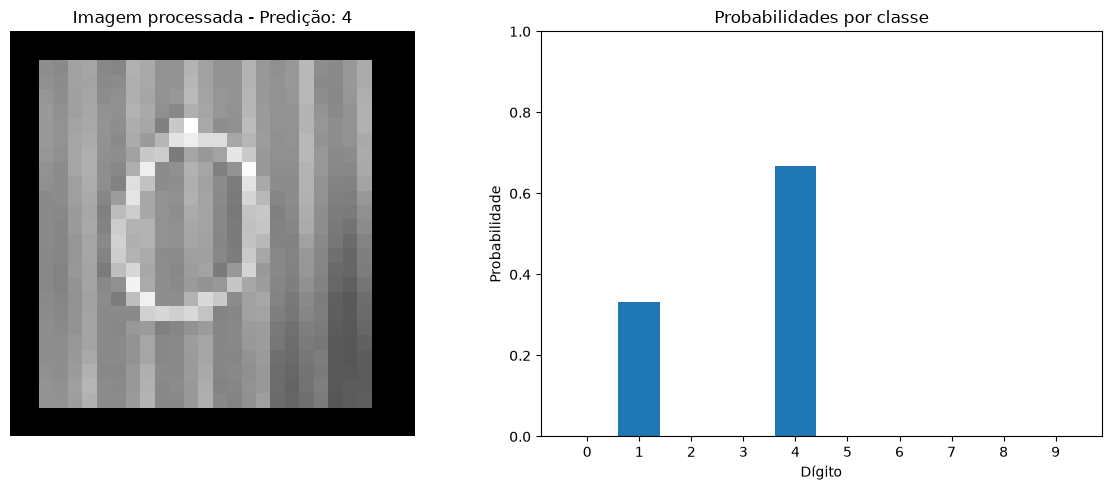

Caminho: C:\Users\franc\OneDrive\Desktop\Projetos\Curso\MNIST_Classification\imagens\minhas_imagens\resultado_0.png
Arquivo existe: True


In [95]:
pasta_imagens = Path("../imagens/minhas_imagens")
pasta_imagens.mkdir(parents=True, exist_ok=True)

caminho = pasta_imagens / "0.jpg"

imagem_processada, _, imagem_modelo = preprocessar_imagem(caminho)

digito_predito, probabilidades = prever_imagem(
    modelo_knn,
    imagem_modelo
)

fig, eixos = plt.subplots(1, 2, figsize=(12, 5))

eixos[0].imshow(imagem_processada, cmap="gray")
eixos[0].set_title(
    f"Imagem processada - Predição: {digito_predito}"
)
eixos[0].axis("off")

eixos[1].bar(modelo_knn.classes_, probabilidades)
eixos[1].set_title("Probabilidades por classe")
eixos[1].set_xlabel("Dígito")
eixos[1].set_ylabel("Probabilidade")
eixos[1].set_ylim(0, 1)

plt.tight_layout()

caminho_saida = pasta_imagens / "resultado_0.png"

fig.savefig(
    caminho_saida,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print("Caminho:", caminho_saida.resolve())
print("Arquivo existe:", caminho_saida.exists())

In [85]:
df_resultados = pd.DataFrame(resultados_imagens)

df_resultados

,digito_real,digito_predito,acertou,confianca
0,0,4,False,0.667585
1,1,6,False,0.337458
2,2,2,False,0.666310
3,3,4,False,0.667427
4,4,4,False,0.667068
5,5,1,False,0.669163
6,6,1,False,1.000000
7,7,8,False,0.336257
8,8,2,False,0.333741
9,9,1,False,1.000000


In [86]:
acuracia_imagens_proprias = df_resultados["acertou"].mean()

print(f"Acurácia nas imagens próprias: {acuracia_imagens_proprias:.2%}")

Acurácia nas imagens próprias: 0.00%


In [87]:
print(df_resultados[["digito_real", "digito_predito", "confianca"]])

   digito_real digito_predito  confianca
0            0              4   0.667585
1            1              6   0.337458
2            2              2   0.666310
3            3              4   0.667427
4            4              4   0.667068
5            5              1   0.669163
6            6              1   1.000000
7            7              8   0.336257
8            8              2   0.333741
9            9              1   1.000000


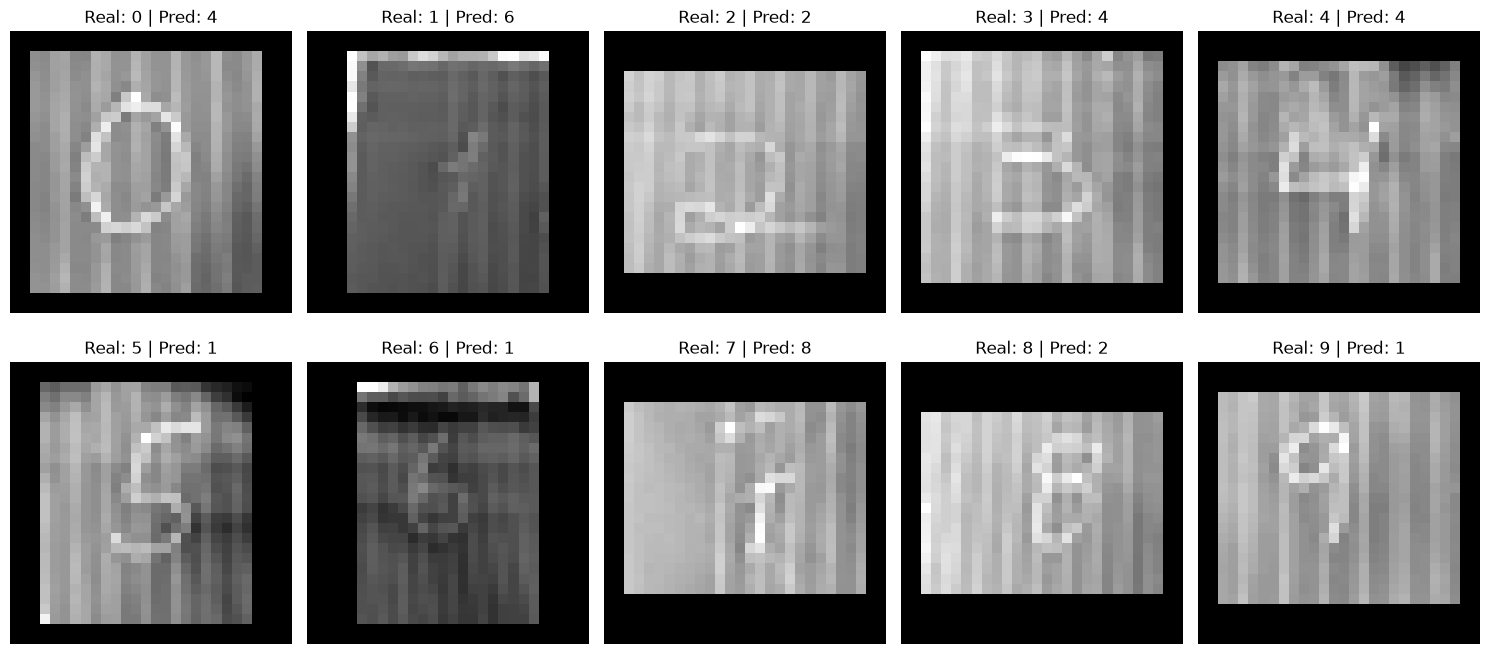

In [88]:

fig, eixos = plt.subplots(2, 5, figsize=(15, 7))
eixos = eixos.ravel()

for digito_real in range(10):
    caminho = Path("../imagens/minhas_imagens") / f"{digito_real}.jpg"

    imagem_processada, _, imagem_modelo = preprocessar_imagem(caminho)

    digito_predito, probabilidades = prever_imagem(
        modelo_knn,
        imagem_modelo
    )

    eixos[digito_real].imshow(imagem_processada, cmap="gray")
    eixos[digito_real].set_title(
        f"Real: {digito_real} | Pred: {digito_predito}"
    )
    eixos[digito_real].axis("off")

plt.tight_layout()
plt.show()

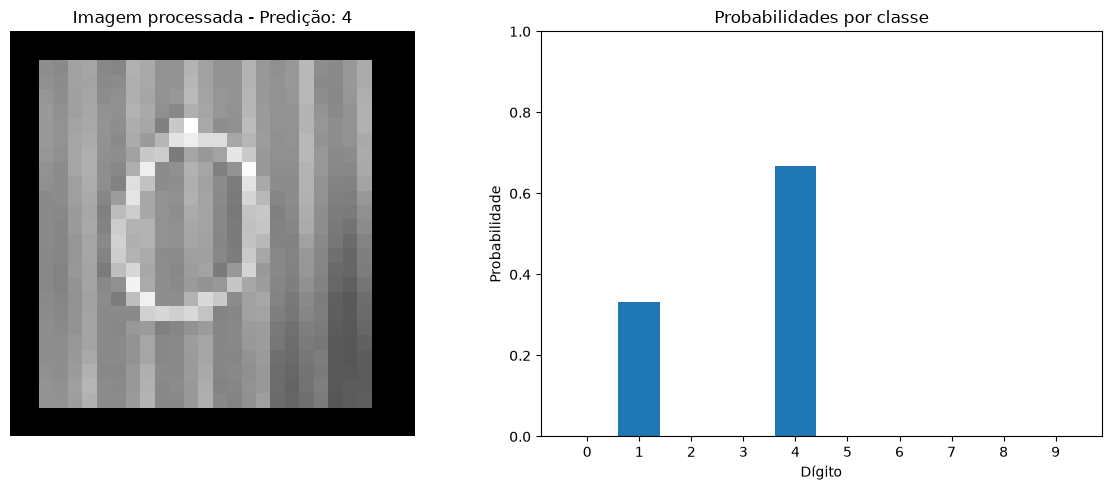

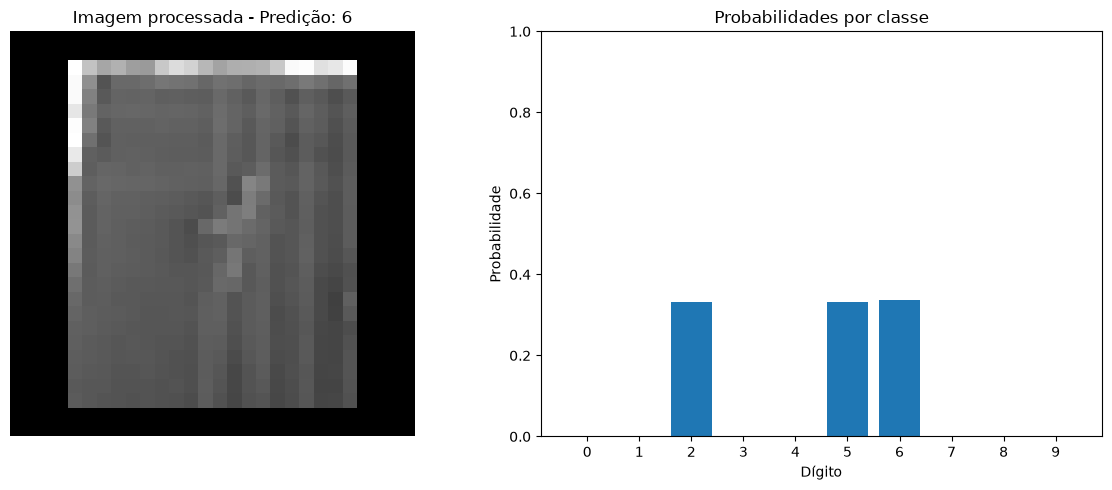

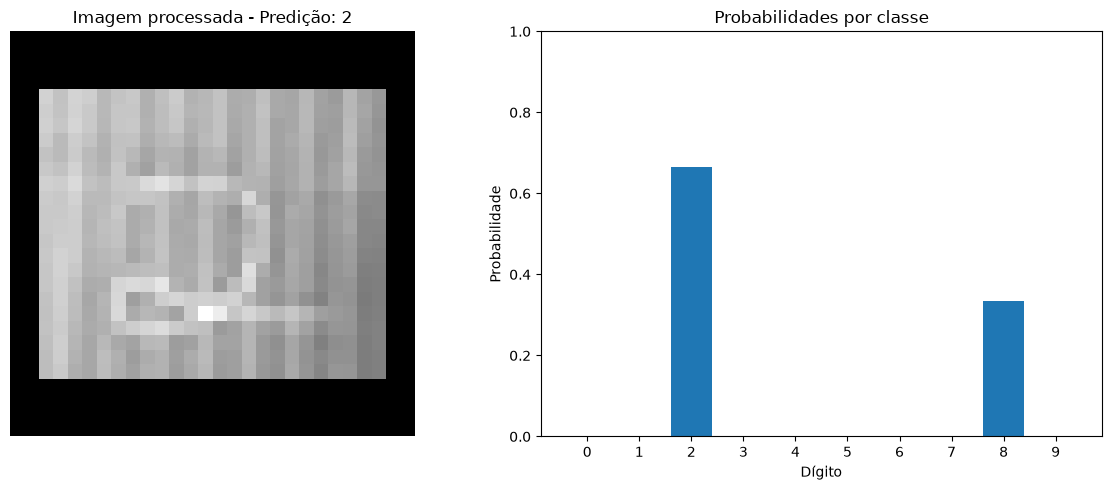

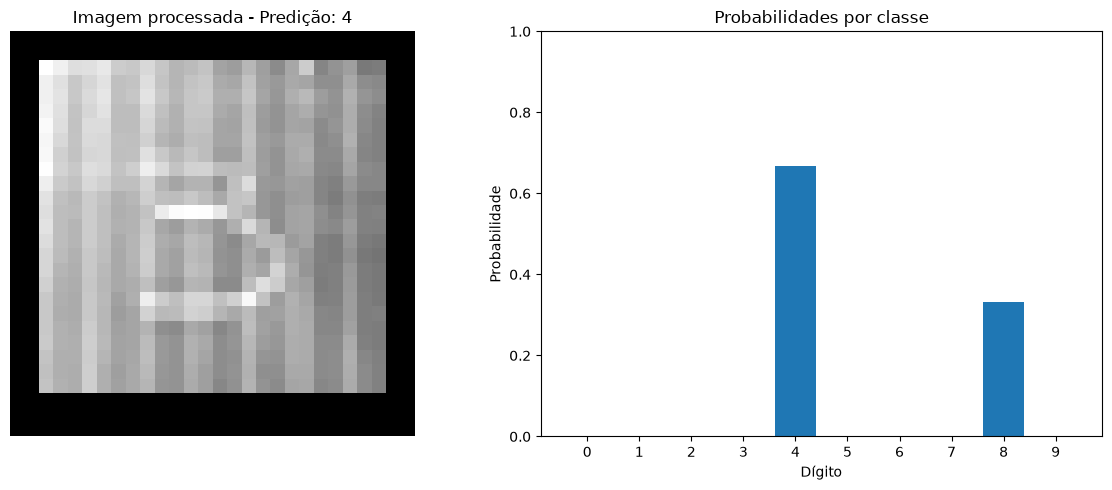

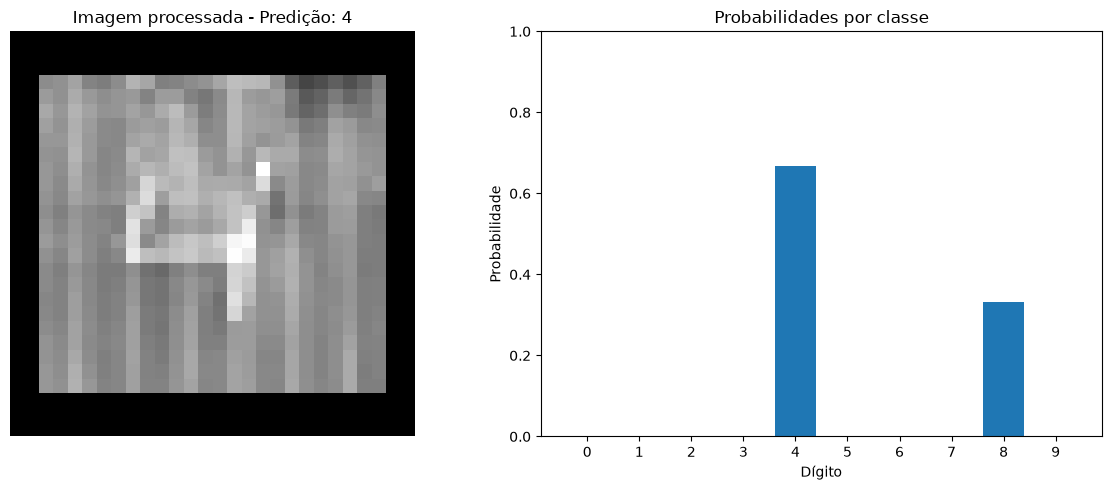

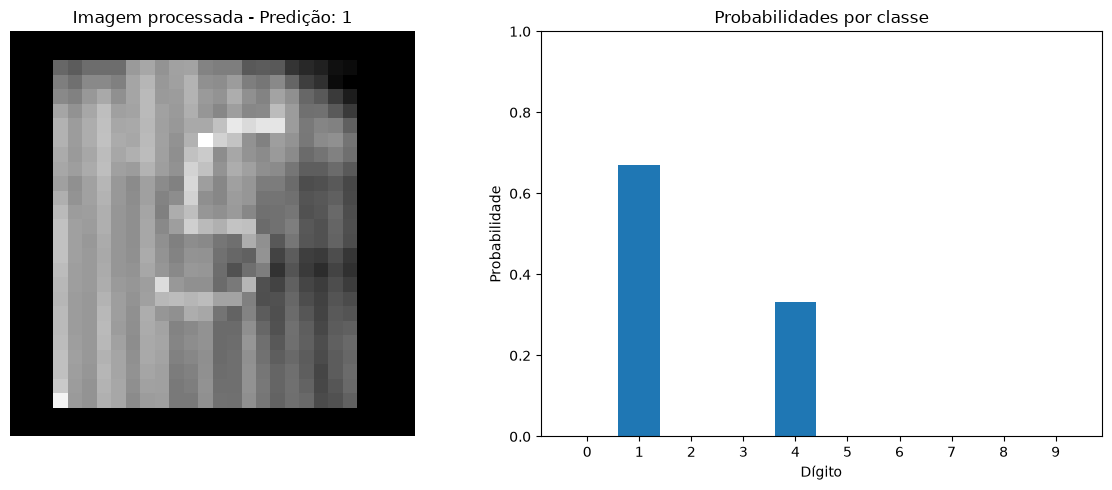

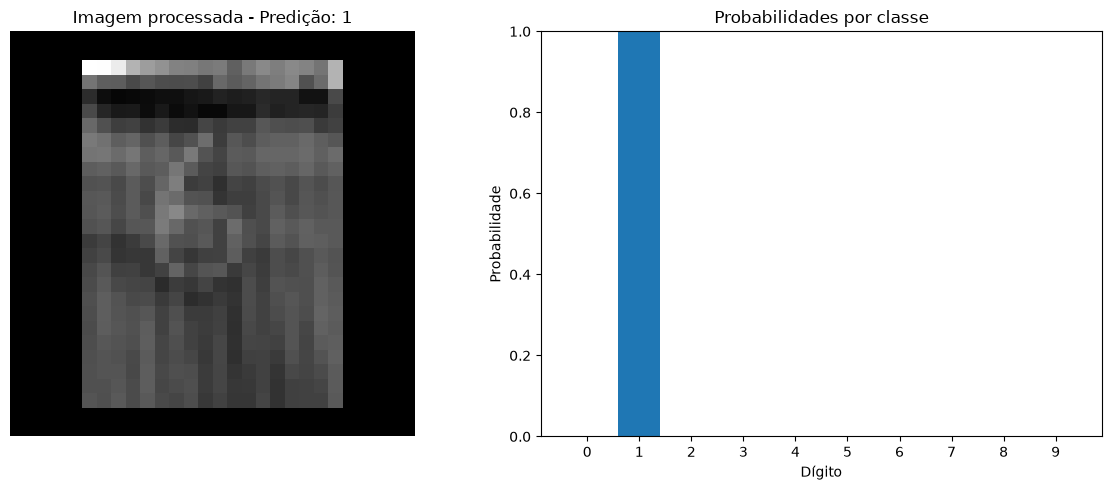

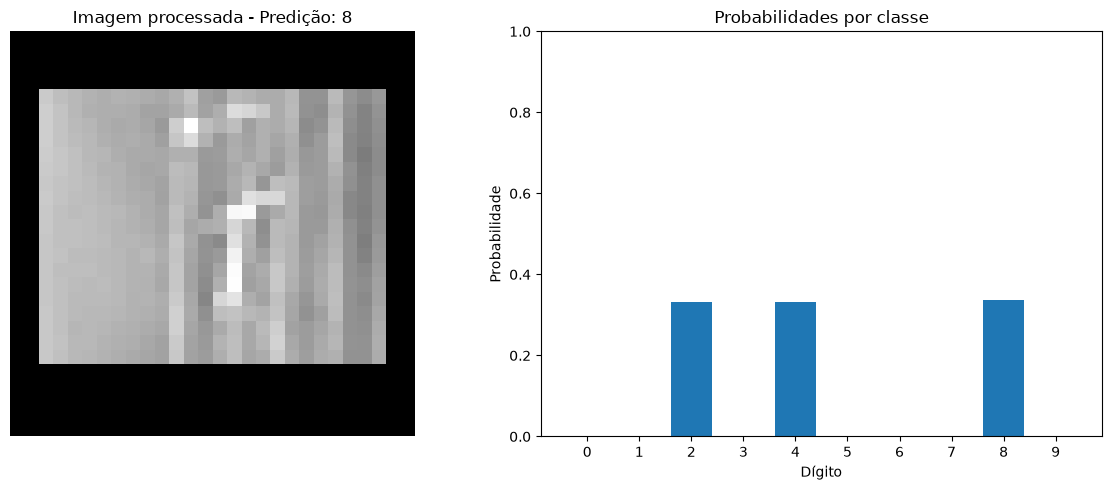

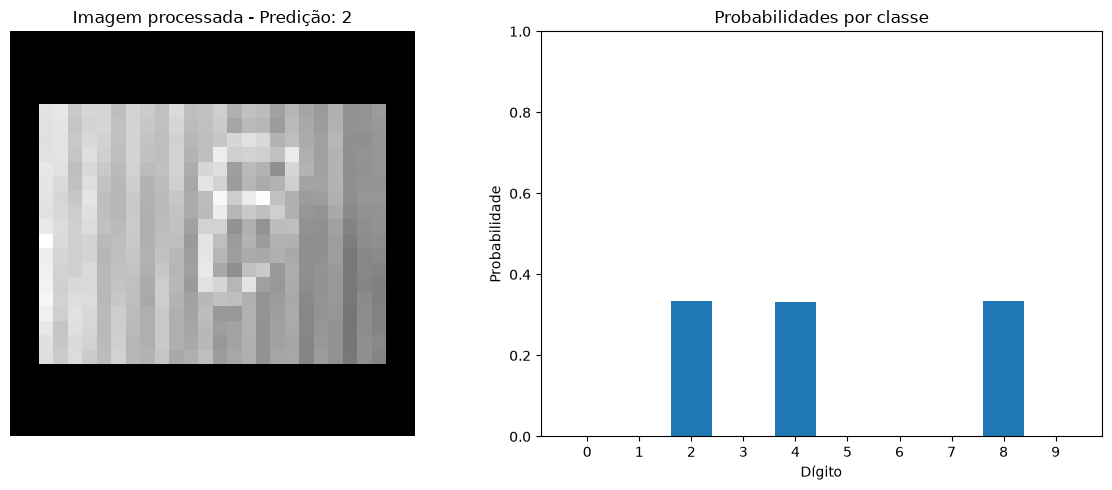

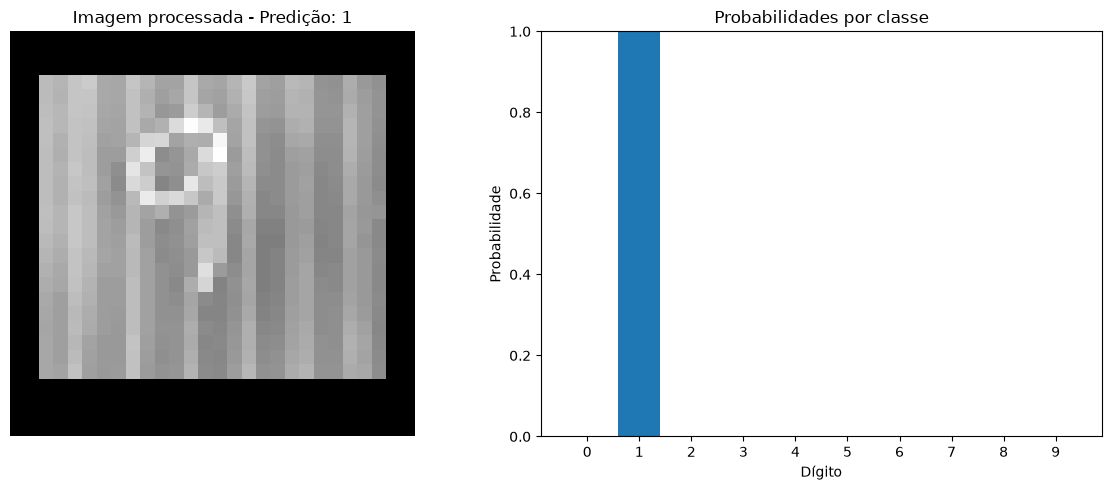

10 gráficos gerados e salvos.


In [96]:
pasta_imagens = Path("../imagens/minhas_imagens")

for digito_real in range(10):

    caminho = pasta_imagens / f"{digito_real}.jpg"

    imagem_processada, _, imagem_modelo = preprocessar_imagem(caminho)

    digito_predito, probabilidades = prever_imagem(
        modelo_knn,
        imagem_modelo
    )

    plotar_previsao(
        imagem_processada,
        digito_predito,
        probabilidades,
        modelo_knn.classes_,
        nome_arquivo=f"resultado_{digito_real}.png"
    )

print("10 gráficos gerados e salvos.")

In [90]:
print("Resultados das imagens próprias")
print("-" * 40)

total = len(df_resultados)
acertos = df_resultados["acertou"].sum()
erros = total - acertos
acuracia = df_resultados["acertou"].mean()

print(f"Total de imagens: {total}")
print(f"Acertos: {acertos}")
print(f"Erros: {erros}")
print(f"Acurácia: {acuracia:.2%}")
print(f"Confiança média: {df_resultados['confianca'].mean():.2%}")

Resultados das imagens próprias
----------------------------------------
Total de imagens: 10
Acertos: 0
Erros: 10
Acurácia: 0.00%
Confiança média: 63.45%


### **Conclusão**

O melhor modelo identificado na avaliação comparativa, o **KNN**, foi utilizado para realizar previsões sobre 10 imagens manuscritas próprias, correspondentes aos dígitos de 0 a 9. As imagens foram submetidas ao pipeline de pré-processamento desenvolvido, incluindo conversão para escala de cinza, aumento de contraste, inversão de cores, identificação da região do dígito, centralização, redimensionamento para 28×28 pixels e normalização dos valores para o intervalo [0,1].

Nos resultados obtidos, o modelo apresentou **0,00% de acurácia**, com nenhuma das 10 imagens sendo classificada corretamente de acordo com o dígito real utilizado como referência. A confiança média das previsões foi de **63,45%**.

Esse resultado evidencia uma limitação importante de generalização. Embora o KNN tenha apresentado excelente desempenho sobre o conjunto de teste do MNIST na Fase 4, as imagens manuscritas próprias possuem características visuais diferentes das imagens utilizadas durante o treinamento, como estilo de escrita, formato dos dígitos, espessura dos traços, escala e distribuição dos pixels.

Também foram observadas previsões com confiança elevada mesmo quando o modelo estava incorreto. Em dois casos, os dígitos 6 e 9 foram classificados como 1 com **100% de confiança**. Esse comportamento demonstra que uma alta confiança na saída do modelo não garante que a classificação esteja correta quando os dados apresentam características diferentes das observadas durante o treinamento.

Portanto, o experimento demonstra que um modelo pode apresentar excelente desempenho em dados semelhantes aos utilizados no treinamento e, ainda assim, apresentar dificuldade significativa quando aplicado a imagens reais produzidas fora desse padrão. Os resultados reforçam a importância de avaliar a capacidade de generalização dos modelos em diferentes condições de entrada.


### **Conclusão da Fase 5 - Robustez e Generalização**

A Fase 5 teve como objetivo avaliar a capacidade de generalização dos modelos diante de situações diferentes daquelas observadas durante o treinamento. Para isso, foram realizados três experimentos complementares: **Class Masking**, **generalização extrema com classes ocultadas** e **predição sobre imagens manuscritas próprias**.

No experimento de **Class Masking**, as classes 4 e 7 foram completamente removidas do conjunto de treinamento. O modelo Random Forest foi treinado utilizando somente as oito classes restantes, confirmando que não teve acesso às classes ocultadas durante o processo de aprendizagem.

Na etapa de **generalização extrema**, o mesmo modelo foi submetido exclusivamente a exemplos das classes 4 e 7, que nunca haviam sido apresentadas durante o treinamento. O classificador foi obrigado a associar essas imagens a alguma das classes conhecidas. Observou-se uma forte concentração das previsões na classe 9: **93,11% das imagens da classe 4 e 74,09% das imagens da classe 7 foram classificadas como 9**. Além disso, foram observadas previsões com alta confiança, incluindo casos com confiança superior a 95%. Esse comportamento evidencia uma situação de **falsa certeza (overconfidence)**, na qual o modelo produz uma previsão confiante mesmo diante de uma classe que não faz parte do seu conhecimento.

Por fim, o melhor modelo identificado na avaliação comparativa da Fase 4, o **KNN**, foi utilizado para classificar 10 imagens manuscritas próprias. Apesar de o modelo ter apresentado **97,21% de acurácia no conjunto de teste do MNIST**, sua acurácia nas imagens próprias foi de **0,00%**, com nenhuma das 10 imagens sendo classificada corretamente. A confiança média das previsões foi de **63,45%**, e alguns erros apresentaram confiança de até 100%.

Os resultados dos três experimentos demonstram que um bom desempenho em um conjunto de teste não garante, por si só, uma boa capacidade de generalização para dados diferentes dos utilizados durante o treinamento.

O **Class Masking** mostrou que o modelo pode ser treinado sem acesso a determinadas classes, enquanto o experimento de **generalização extrema** demonstrou que, mesmo diante de classes completamente desconhecidas, o classificador pode produzir previsões com alta confiança. Já o experimento com **imagens manuscritas próprias** evidenciou que mudanças na aparência e na distribuição dos dados podem provocar uma queda significativa no desempenho, mesmo quando o modelo apresenta excelente desempenho sobre o conjunto de teste original.

Dessa forma, a Fase 5 evidencia a importância de avaliar não apenas o desempenho preditivo de um modelo em dados semelhantes aos utilizados no treinamento, mas também seu comportamento diante de **classes desconhecidas e dados fora do padrão esperado**. Os experimentos realizados permitiram identificar limitações de generalização que não seriam observadas apenas pelas métricas tradicionais de desempenho utilizadas nas etapas anteriores.

